In [1]:
print("Jupyter is working!")


print("Jupyter is working!")

Jupyter is working!
Jupyter is working!


In [2]:
print("Jupyter is working!")

Jupyter is working!


In [3]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.5
NumPy version: 2.5.2


In [4]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)


Pandas version: 3.0.5
NumPy version: 2.5.2


In [5]:
from pathlib import Path

json_folder = Path("../data/raw/ipl_json")

json_files = list(json_folder.glob("*.json"))

print("Number of JSON files:", len(json_files))

for file in json_files[:5]:
    print(file)

Number of JSON files: 1243
..\data\raw\ipl_json\1082591.json
..\data\raw\ipl_json\1082592.json
..\data\raw\ipl_json\1082593.json
..\data\raw\ipl_json\1082594.json
..\data\raw\ipl_json\1082595.json


In [6]:
import json

first_file = json_files[0]

with open(first_file, "r", encoding="utf-8") as f:
    match_data = json.load(f)

print(type(match_data))
print(match_data.keys())

<class 'dict'>
dict_keys(['meta', 'info', 'innings'])


In [7]:
print("META:")
print(match_data["meta"])

print("\nINFO:")
print(match_data["info"].keys())

print("\nNUMBER OF INNINGS:", len(match_data["innings"]))


META:
{'data_version': '1.2.0', 'created': '2017-04-06', 'revision': 1}

INFO:
dict_keys(['balls_per_over', 'city', 'dates', 'event', 'gender', 'match_type', 'officials', 'outcome', 'overs', 'player_of_match', 'players', 'registry', 'season', 'team_type', 'teams', 'toss', 'venue'])

NUMBER OF INNINGS: 2


In [8]:
info = match_data["info"]

print("Teams:", info["teams"])
print("Date:", info["dates"])
print("Season:", info["season"])
print("Venue:", info["venue"])
print("Toss:", info["toss"])
print("Outcome:", info["outcome"])

Teams: ['Sunrisers Hyderabad', 'Royal Challengers Bangalore']
Date: ['2017-04-05']
Season: 2017
Venue: Rajiv Gandhi International Stadium, Uppal
Toss: {'decision': 'field', 'winner': 'Royal Challengers Bangalore'}
Outcome: {'by': {'runs': 35}, 'winner': 'Sunrisers Hyderabad'}


In [9]:
print(match_data["innings"][0].keys())

dict_keys(['team', 'overs', 'powerplays'])


In [10]:
first_innings = match_data["innings"][0]

print("Batting team:", first_innings["team"])
print("Number of overs:", len(first_innings["overs"]))

print("\nFirst over:")
print(first_innings["overs"][0])

Batting team: Sunrisers Hyderabad
Number of overs: 20

First over:
{'over': 0, 'deliveries': [{'actual_delivery': '0.1', 'batter': 'DA Warner', 'bowler': 'TS Mills', 'non_striker': 'S Dhawan', 'runs': {'batter': 0, 'extras': 0, 'total': 0}}, {'actual_delivery': '0.2', 'batter': 'DA Warner', 'bowler': 'TS Mills', 'non_striker': 'S Dhawan', 'runs': {'batter': 0, 'extras': 0, 'total': 0}}, {'actual_delivery': '0.3', 'batter': 'DA Warner', 'bowler': 'TS Mills', 'non_striker': 'S Dhawan', 'runs': {'batter': 4, 'extras': 0, 'total': 4}}, {'actual_delivery': '0.4', 'batter': 'DA Warner', 'bowler': 'TS Mills', 'non_striker': 'S Dhawan', 'runs': {'batter': 0, 'extras': 0, 'total': 0}}, {'actual_delivery': '0.5', 'batter': 'DA Warner', 'bowler': 'TS Mills', 'extras': {'wides': 2}, 'non_striker': 'S Dhawan', 'runs': {'batter': 0, 'extras': 2, 'total': 2}}, {'actual_delivery': '0.5', 'batter': 'S Dhawan', 'bowler': 'TS Mills', 'non_striker': 'DA Warner', 'runs': {'batter': 0, 'extras': 0, 'total':

In [11]:
import json

first_file = json_files[0]

with open(first_file, "r", encoding="utf-8") as f:
    match_data = json.load(f)

print(type(match_data))
print(match_data.keys())

<class 'dict'>
dict_keys(['meta', 'info', 'innings'])


In [12]:
total_runs = 0

for over in first_innings["overs"]:
    for delivery in over["deliveries"]:
        total_runs += delivery["runs"]["total"]

print("Batting team:", first_innings["team"])
print("Total runs:", total_runs)

Batting team: Sunrisers Hyderabad
Total runs: 207


In [13]:
second_innings = match_data["innings"][1]

total_runs_2 = 0

for over in second_innings["overs"]:
    for delivery in over["deliveries"]:
        total_runs_2 += delivery["runs"]["total"]

print("Batting team:", second_innings["team"])
print("Total runs:", total_runs_2)

Batting team: Royal Challengers Bangalore
Total runs: 172


In [14]:
match_summary = {
    "season": info["season"],
    "date": info["dates"][0],
    "team_1": match_data["innings"][0]["team"],
    "team_1_score": total_runs,
    "team_2": match_data["innings"][1]["team"],
    "team_2_score": total_runs_2,
    "winner": info["outcome"]["winner"]
}

match_summary


{'season': 2017,
 'date': '2017-04-05',
 'team_1': 'Sunrisers Hyderabad',
 'team_1_score': 207,
 'team_2': 'Royal Challengers Bangalore',
 'team_2_score': 172,
 'winner': 'Sunrisers Hyderabad'}

In [15]:
def extract_match_data(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match["info"]
    innings = match["innings"]

    # Skip matches that don't have exactly 2 innings
    if len(innings) != 2:
        return None

    scores = []

    for inning in innings:
        score = 0

        for over in inning["overs"]:
            for delivery in over["deliveries"]:
                score += delivery["runs"]["total"]

        scores.append(score)

    return {
        "season": info["season"],
        "date": info["dates"][0],
        "team_1": innings[0]["team"],
        "team_1_score": scores[0],
        "team_2": innings[1]["team"],
        "team_2_score": scores[1],
        "winner": info["outcome"].get("winner")
    }
    

In [16]:
def extract_match_data(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match["info"]
    innings = match["innings"]

    # Skip matches that don't have exactly 2 innings
    if len(innings) != 2:
        return None

    scores = []

    for inning in innings:
        score = 0

        for over in inning["overs"]:
            for delivery in over["deliveries"]:
                score += delivery["runs"]["total"]

        scores.append(score)

    return {
        "season": info["season"],
        "date": info["dates"][0],
        "team_1": innings[0]["team"],
        "team_1_score": scores[0],
        "team_2": innings[1]["team"],
        "team_2_score": scores[1],
        "winner": info["outcome"].get("winner")
    }

In [17]:
test_match = extract_match_data(json_files[0])

print(test_match)



{'season': 2017, 'date': '2017-04-05', 'team_1': 'Sunrisers Hyderabad', 'team_1_score': 207, 'team_2': 'Royal Challengers Bangalore', 'team_2_score': 172, 'winner': 'Sunrisers Hyderabad'}


In [18]:
all_matches = []

for file in json_files:
    match = extract_match_data(file)

    if match is not None:
        all_matches.append(match)

print("Matches extracted:", len(all_matches))

Matches extracted: 1221


In [19]:
df = pd.DataFrame(all_matches)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 1221
Columns: 7


,season,date,team_1,team_1_score,team_2,team_2_score,winner
0,2017,2017-04-05,Sunrisers Hyderabad,207,Royal Challengers Bangalore,172,Sunrisers Hyderabad
1,2017,2017-04-06,Mumbai Indians,184,Rising Pune Supergiant,187,Rising Pune Supergiant
2,2017,2017-04-07,Gujarat Lions,183,Kolkata Knight Riders,184,Kolkata Knight Riders
3,2017,2017-04-08,Rising Pune Supergiant,163,Kings XI Punjab,164,Kings XI Punjab
4,2017,2017-04-08,Royal Challengers Bangalore,157,Delhi Daredevils,142,Royal Challengers Bangalore


In [20]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (1221, 7)

Column names:
['season', 'date', 'team_1', 'team_1_score', 'team_2', 'team_2_score', 'winner']

Missing values:
season          0
date            0
team_1          0
team_1_score    0
team_2          0
team_2_score    0
winner          3
dtype: int64

Data types:
season          object
date               str
team_1             str
team_1_score     int64
team_2             str
team_2_score     int64
winner             str
dtype: object


In [21]:
missing_winners = df[df["winner"].isna()]

print("Matches with missing winner:", len(missing_winners))

missing_winners

Matches with missing winner: 3


,season,date,team_1,team_1_score,team_2,team_2_score,winner
165,2019,2019-04-30,Royal Challengers Bangalore,62,Rajasthan Royals,41,NaN
551,2025,2025-04-26,Punjab Kings,201,Kolkata Knight Riders,7,NaN
1155,2015,2015-05-17,Delhi Daredevils,187,Royal Challengers Bangalore,2,NaN


In [22]:
for index in missing_winners.index:
    print("\n" + "=" * 70)
    print("ROW INDEX:", index)
    print("Season:", df.loc[index, "season"])
    print("Date:", df.loc[index, "date"])
    print("Teams:", df.loc[index, "team_1"], "vs", df.loc[index, "team_2"])
    print("Score:", df.loc[index, "team_1_score"], "-", df.loc[index, "team_2_score"])


ROW INDEX: 165
Season: 2019
Date: 2019-04-30
Teams: Royal Challengers Bangalore vs Rajasthan Royals
Score: 62 - 41

ROW INDEX: 551
Season: 2025
Date: 2025-04-26
Teams: Punjab Kings vs Kolkata Knight Riders
Score: 201 - 7

ROW INDEX: 1155
Season: 2015
Date: 2015-05-17
Teams: Delhi Daredevils vs Royal Challengers Bangalore
Score: 187 - 2


In [23]:
for index in missing_winners.index:
    print("\n" + "=" * 80)
    print("INDEX:", index)
    print("DATE:", df.loc[index, "date"])
    print("TEAMS:", df.loc[index, "team_1"], "vs", df.loc[index, "team_2"])

    # Find the JSON file used for this row
    print("JSON FILE:", json_files[index])
    


INDEX: 165
DATE: 2019-04-30
TEAMS: Royal Challengers Bangalore vs Rajasthan Royals
JSON FILE: ..\data\raw\ipl_json\1178422.json

INDEX: 551
DATE: 2025-04-26
TEAMS: Punjab Kings vs Kolkata Knight Riders
JSON FILE: ..\data\raw\ipl_json\1473471.json

INDEX: 1155
DATE: 2015-05-17
TEAMS: Delhi Daredevils vs Royal Challengers Bangalore
JSON FILE: ..\data\raw\ipl_json\829769.json


In [24]:
import json

problem_files = [
    r"..\data\raw\ipl_json\1178422.json",
    r"..\data\raw\ipl_json\1473471.json",
    r"..\data\raw\ipl_json\829769.json"
]

for file in problem_files:
    print("\n" + "=" * 80)
    print("FILE:", file)

    with open(file, "r", encoding="utf-8") as f:
        match = json.load(f)

    print("Teams:", match["info"]["teams"])
    print("Outcome:", match["info"]["outcome"])


FILE: ..\data\raw\ipl_json\1178422.json
Teams: ['Kolkata Knight Riders', 'Mumbai Indians']
Outcome: {'winner': 'Kolkata Knight Riders', 'by': {'runs': 34}}

FILE: ..\data\raw\ipl_json\1473471.json
Teams: ['Royal Challengers Bengaluru', 'Punjab Kings']
Outcome: {'winner': 'Punjab Kings', 'by': {'wickets': 5}}

FILE: ..\data\raw\ipl_json\829769.json
Teams: ['Mumbai Indians', 'Rajasthan Royals']
Outcome: {'by': {'runs': 8}, 'winner': 'Mumbai Indians'}


In [25]:
match_records = []

for file in json_files:
    with open(file, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match["info"]
    innings = match["innings"]

    # Only use matches with exactly 2 innings
    if len(innings) != 2:
        continue

    team_1 = innings[0]["team"]
    team_2 = innings[1]["team"]

    team_1_score = sum(
        delivery["runs"]["total"]
        for over in innings[0]["overs"]
        for delivery in over["deliveries"]
    )

    team_2_score = sum(
        delivery["runs"]["total"]
        for over in innings[1]["overs"]
        for delivery in over["deliveries"]
    )

    winner = info.get("outcome", {}).get("winner")

    match_records.append({
        "season": info["season"],
        "date": str(info["dates"][0]),
        "team_1": team_1,
        "team_1_score": team_1_score,
        "team_2": team_2,
        "team_2_score": team_2_score,
        "winner": winner,
        "json_file": file
    })

df = pd.DataFrame(match_records)

print("Matches extracted:", len(df))
print("Missing winners:", df["winner"].isna().sum())


Matches extracted: 1221
Missing winners: 3


In [26]:
missing_winners = df[df["winner"].isna()]

missing_winners

,season,date,team_1,team_1_score,team_2,team_2_score,winner,json_file
165,2019,2019-04-30,Royal Challengers Bangalore,62,Rajasthan Royals,41,NaN,..\data\raw\ipl_json\1178424.json
551,2025,2025-04-26,Punjab Kings,201,Kolkata Knight Riders,7,NaN,..\data\raw\ipl_json\1473481.json
1155,2015,2015-05-17,Delhi Daredevils,187,Royal Challengers Bangalore,2,NaN,..\data\raw\ipl_json\829813.json


In [27]:
for file in missing_winners["json_file"]:
    print("\n" + "=" * 80)
    print("FILE:", file)

    with open(file, "r", encoding="utf-8") as f:
        match = json.load(f)

    print("Teams:", match["info"]["teams"])
    print("Date:", match["info"]["dates"])
    print("Outcome:", match["info"]["outcome"])
    print("Number of innings:", len(match["innings"]))


FILE: ..\data\raw\ipl_json\1178424.json
Teams: ['Royal Challengers Bangalore', 'Rajasthan Royals']
Date: ['2019-04-30']
Outcome: {'result': 'no result'}
Number of innings: 2

FILE: ..\data\raw\ipl_json\1473481.json
Teams: ['Punjab Kings', 'Kolkata Knight Riders']
Date: ['2025-04-26']
Outcome: {'result': 'no result'}
Number of innings: 2

FILE: ..\data\raw\ipl_json\829813.json
Teams: ['Royal Challengers Bangalore', 'Delhi Daredevils']
Date: ['2015-05-17']
Outcome: {'result': 'no result'}
Number of innings: 2


In [28]:
df = df.dropna(subset=["winner"]).copy()

print("Matches after removing No Result matches:", len(df))
print("Missing winners:", df["winner"].isna().sum())

Matches after removing No Result matches: 1218
Missing winners: 0


In [29]:
print(df.head())

  season        date                       team_1  team_1_score  \
0   2017  2017-04-05          Sunrisers Hyderabad           207   
1   2017  2017-04-06               Mumbai Indians           184   
2   2017  2017-04-07                Gujarat Lions           183   
3   2017  2017-04-08       Rising Pune Supergiant           163   
4   2017  2017-04-08  Royal Challengers Bangalore           157   

                        team_2  team_2_score                       winner  \
0  Royal Challengers Bangalore           172          Sunrisers Hyderabad   
1       Rising Pune Supergiant           187       Rising Pune Supergiant   
2        Kolkata Knight Riders           184        Kolkata Knight Riders   
3              Kings XI Punjab           164              Kings XI Punjab   
4             Delhi Daredevils           142  Royal Challengers Bangalore   

                           json_file  
0  ..\data\raw\ipl_json\1082591.json  
1  ..\data\raw\ipl_json\1082592.json  
2  ..\data\raw\ip

In [30]:
print(df.tail())

     season        date               team_1  team_1_score  \
1216   2016  2016-05-22     Delhi Daredevils           138   
1217   2016  2016-05-24        Gujarat Lions           158   
1218   2016  2016-05-25  Sunrisers Hyderabad           162   
1219   2016  2016-05-27        Gujarat Lions           162   
1220   2016  2016-05-29  Sunrisers Hyderabad           208   

                           team_2  team_2_score                       winner  \
1216  Royal Challengers Bangalore           139  Royal Challengers Bangalore   
1217  Royal Challengers Bangalore           159  Royal Challengers Bangalore   
1218        Kolkata Knight Riders           140          Sunrisers Hyderabad   
1219          Sunrisers Hyderabad           163          Sunrisers Hyderabad   
1220  Royal Challengers Bangalore           200          Sunrisers Hyderabad   

                             json_file  
1216  ..\data\raw\ipl_json\981011.json  
1217  ..\data\raw\ipl_json\981013.json  
1218  ..\data\raw\ipl_j

In [31]:
# Check the final cleaned dataset

print("Final dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of teams:")
teams = sorted(set(df["team_1"]) | set(df["team_2"]))
print(len(teams))

print("\nTeams:")
for team in teams:
    print("-", team)

Final dataset shape: (1218, 8)

Columns:
['season', 'date', 'team_1', 'team_1_score', 'team_2', 'team_2_score', 'winner', 'json_file']

Missing values:
season          0
date            0
team_1          0
team_1_score    0
team_2          0
team_2_score    0
winner          0
json_file       0
dtype: int64

Number of teams:
19

Teams:
- Chennai Super Kings
- Deccan Chargers
- Delhi Capitals
- Delhi Daredevils
- Gujarat Lions
- Gujarat Titans
- Kings XI Punjab
- Kochi Tuskers Kerala
- Kolkata Knight Riders
- Lucknow Super Giants
- Mumbai Indians
- Pune Warriors
- Punjab Kings
- Rajasthan Royals
- Rising Pune Supergiant
- Rising Pune Supergiants
- Royal Challengers Bangalore
- Royal Challengers Bengaluru
- Sunrisers Hyderabad


In [32]:
# Standardize IPL team names

team_name_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}

# Replace old names with current names
df["team_1"] = df["team_1"].replace(team_name_mapping)
df["team_2"] = df["team_2"].replace(team_name_mapping)
df["winner"] = df["winner"].replace(team_name_mapping)

# Check the result
teams = sorted(set(df["team_1"]) | set(df["team_2"]))

print("Number of teams after standardization:", len(teams))
print("\nTeams:")

for team in teams:
    print("-", team)

Number of teams after standardization: 15

Teams:
- Chennai Super Kings
- Deccan Chargers
- Delhi Capitals
- Gujarat Lions
- Gujarat Titans
- Kochi Tuskers Kerala
- Kolkata Knight Riders
- Lucknow Super Giants
- Mumbai Indians
- Pune Warriors
- Punjab Kings
- Rajasthan Royals
- Rising Pune Supergiants
- Royal Challengers Bengaluru
- Sunrisers Hyderabad


In [33]:
# Create the target variable

df["target"] = (df["winner"] == df["team_2"]).astype(int)

print("Target created successfully!")
print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nFirst 5 rows:")
display(df[["team_1", "team_2", "winner", "target"]].head())

Target created successfully!

Target distribution:
target
1    666
0    552
Name: count, dtype: int64

First 5 rows:


,team_1,team_2,winner,target
0,Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,0
1,Mumbai Indians,Rising Pune Supergiants,Rising Pune Supergiants,1
2,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,1
3,Rising Pune Supergiants,Punjab Kings,Punjab Kings,1
4,Royal Challengers Bengaluru,Delhi Capitals,Royal Challengers Bengaluru,0


In [34]:
# Create machine-learning features

X = df[["team_1", "team_2"]]
y = df["target"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):


,team_1,team_2
0,Sunrisers Hyderabad,Royal Challengers Bengaluru
1,Mumbai Indians,Rising Pune Supergiants
2,Gujarat Lions,Kolkata Knight Riders
3,Rising Pune Supergiants,Punjab Kings
4,Royal Challengers Bengaluru,Delhi Capitals



Target (y):


0    0
1    1
2    1
3    1
4    0
Name: target, dtype: int64


X shape: (1218, 2)
y shape: (1218,)


In [35]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_encoded = encoder.fit_transform(X)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)
print("Number of encoded features:", X_encoded.shape[1])

Original X shape: (1218, 2)
Encoded X shape: (1218, 30)
Number of encoded features: 30


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (974, 30)
X_test shape: (244, 30)
y_train shape: (974,)
y_test shape: (244,)


In [37]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [38]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed!
First 20 predictions:
[1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0]


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.5327868852459017
Model Accuracy (%): 53.278688524590166


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 28  83]
 [ 31 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.25      0.33       111
           1       0.55      0.77      0.64       133

    accuracy                           0.53       244
   macro avg       0.51      0.51      0.49       244
weighted avg       0.52      0.53      0.50       244



In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

# Make predictions
rf_y_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_y_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest training completed!
Random Forest Accuracy: 0.5614754098360656
Random Forest Accuracy (%): 56.14754098360656


In [42]:
# Random Forest evaluation

rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

Random Forest Confusion Matrix:
[[51 60]
 [47 86]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.46      0.49       111
           1       0.59      0.65      0.62       133

    accuracy                           0.56       244
   macro avg       0.55      0.55      0.55       244
weighted avg       0.56      0.56      0.56       244



In [43]:
# Sort matches chronologically
df = df.sort_values("date").reset_index(drop=True)

print("Dataset sorted by date!")
print(df[["date", "team_1", "team_2", "winner"]].head())

Dataset sorted by date!
         date                 team_1                       team_2  \
0  2008-04-18  Kolkata Knight Riders  Royal Challengers Bengaluru   
1  2008-04-19    Chennai Super Kings                 Punjab Kings   
2  2008-04-19       Rajasthan Royals               Delhi Capitals   
3  2008-04-20        Deccan Chargers        Kolkata Knight Riders   
4  2008-04-20         Mumbai Indians  Royal Challengers Bengaluru   

                        winner  
0        Kolkata Knight Riders  
1          Chennai Super Kings  
2               Delhi Capitals  
3        Kolkata Knight Riders  
4  Royal Challengers Bengaluru  


In [44]:
# Create historical win-rate features

team_wins = {}
team_matches = {}

team_1_win_rate = []
team_2_win_rate = []

for _, row in df.iterrows():
    team1 = row["team_1"]
    team2 = row["team_2"]

    # Win rate BEFORE this match
    team1_rate = team_wins.get(team1, 0) / team_matches.get(team1, 0) if team_matches.get(team1, 0) > 0 else 0.5
    team2_rate = team_wins.get(team2, 0) / team_matches.get(team2, 0) if team_matches.get(team2, 0) > 0 else 0.5

    team_1_win_rate.append(team1_rate)
    team_2_win_rate.append(team2_rate)

    # Update history AFTER the match
    winner = row["winner"]

    team_matches[team1] = team_matches.get(team1, 0) + 1
    team_matches[team2] = team_matches.get(team2, 0) + 1

    if winner == team1:
        team_wins[team1] = team_wins.get(team1, 0) + 1
    else:
        team_wins[team2] = team_wins.get(team2, 0) + 1

# Add features to dataframe
df["team_1_win_rate"] = team_1_win_rate
df["team_2_win_rate"] = team_2_win_rate

print("Historical win-rate features created!")

print(df[
    [
        "date",
        "team_1",
        "team_2",
        "winner",
        "team_1_win_rate",
        "team_2_win_rate"
    ]
].head(10))

Historical win-rate features created!
         date                 team_1                       team_2  \
0  2008-04-18  Kolkata Knight Riders  Royal Challengers Bengaluru   
1  2008-04-19    Chennai Super Kings                 Punjab Kings   
2  2008-04-19       Rajasthan Royals               Delhi Capitals   
3  2008-04-20        Deccan Chargers        Kolkata Knight Riders   
4  2008-04-20         Mumbai Indians  Royal Challengers Bengaluru   
5  2008-04-21           Punjab Kings             Rajasthan Royals   
6  2008-04-22        Deccan Chargers               Delhi Capitals   
7  2008-04-23    Chennai Super Kings               Mumbai Indians   
8  2008-04-24        Deccan Chargers             Rajasthan Royals   
9  2008-04-25           Punjab Kings               Mumbai Indians   

                        winner  team_1_win_rate  team_2_win_rate  
0        Kolkata Knight Riders              0.5              0.5  
1          Chennai Super Kings              0.5              0.5  
2

In [45]:
# Create win-rate difference

df["win_rate_difference"] = (
    df["team_1_win_rate"] - df["team_2_win_rate"]
)

print("Win-rate difference feature created!")

print(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_win_rate",
            "team_2_win_rate",
            "win_rate_difference"
        ]
    ].head(10)
)

Win-rate difference feature created!
         date                 team_1                       team_2  \
0  2008-04-18  Kolkata Knight Riders  Royal Challengers Bengaluru   
1  2008-04-19    Chennai Super Kings                 Punjab Kings   
2  2008-04-19       Rajasthan Royals               Delhi Capitals   
3  2008-04-20        Deccan Chargers        Kolkata Knight Riders   
4  2008-04-20         Mumbai Indians  Royal Challengers Bengaluru   
5  2008-04-21           Punjab Kings             Rajasthan Royals   
6  2008-04-22        Deccan Chargers               Delhi Capitals   
7  2008-04-23    Chennai Super Kings               Mumbai Indians   
8  2008-04-24        Deccan Chargers             Rajasthan Royals   
9  2008-04-25           Punjab Kings               Mumbai Indians   

                        winner  team_1_win_rate  team_2_win_rate  \
0        Kolkata Knight Riders              0.5              0.5   
1          Chennai Super Kings              0.5              0.5   

In [46]:
# Create features and target

X = df[
    [
        "team_1_win_rate",
        "team_2_win_rate",
        "win_rate_difference"
    ]
]

y = df["target"]

print("New X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.head())

New X shape: (1218, 3)
y shape: (1218,)

Features:
   team_1_win_rate  team_2_win_rate  win_rate_difference
0              0.5              0.5                  0.0
1              0.5              0.5                  0.0
2              0.5              0.5                  0.0
3              0.5              1.0                 -0.5
4              0.5              0.0                  0.5


In [47]:
# Time-based train-test split

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (974, 3)
X_test shape: (244, 3)
y_train shape: (974,)
y_test shape: (244,)


In [48]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [49]:
# Make predictions
rf_predictions = rf_model.predict(X_test)

print("Predictions completed!")
print("First 20 predictions:")
print(rf_predictions[:20])

Predictions completed!
First 20 predictions:
[1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 0]


In [50]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.48770491803278687
Random Forest Accuracy (%): 48.77049180327869


In [51]:
# Create historical head-to-head win-rate feature

head_to_head = {}

team_1_h2h_rate = []
team_2_h2h_rate = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Create a consistent pair for the two teams
    pair = tuple(sorted([team1, team2]))

    # Get previous head-to-head record
    if pair in head_to_head:
        team1_wins = head_to_head[pair].get(team1, 0)
        team2_wins = head_to_head[pair].get(team2, 0)

        total_matches = team1_wins + team2_wins

        if total_matches > 0:
            team1_rate = team1_wins / total_matches
            team2_rate = team2_wins / total_matches
        else:
            team1_rate = 0.5
            team2_rate = 0.5
    else:
        team1_rate = 0.5
        team2_rate = 0.5

    team_1_h2h_rate.append(team1_rate)
    team_2_h2h_rate.append(team2_rate)

    # Update head-to-head history AFTER the match
    winner = row["winner"]

    if pair not in head_to_head:
        head_to_head[pair] = {}

    head_to_head[pair][winner] = head_to_head[pair].get(winner, 0) + 1


# Add features to dataframe
df["team_1_h2h_rate"] = team_1_h2h_rate
df["team_2_h2h_rate"] = team_2_h2h_rate

# Difference
df["h2h_difference"] = (
    df["team_1_h2h_rate"] - df["team_2_h2h_rate"]
)

print("Head-to-head features created!")

print(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_h2h_rate",
            "team_2_h2h_rate",
            "h2h_difference"
        ]
    ].head(15)
)

Head-to-head features created!
          date                       team_1                       team_2  \
0   2008-04-18        Kolkata Knight Riders  Royal Challengers Bengaluru   
1   2008-04-19          Chennai Super Kings                 Punjab Kings   
2   2008-04-19             Rajasthan Royals               Delhi Capitals   
3   2008-04-20              Deccan Chargers        Kolkata Knight Riders   
4   2008-04-20               Mumbai Indians  Royal Challengers Bengaluru   
5   2008-04-21                 Punjab Kings             Rajasthan Royals   
6   2008-04-22              Deccan Chargers               Delhi Capitals   
7   2008-04-23          Chennai Super Kings               Mumbai Indians   
8   2008-04-24              Deccan Chargers             Rajasthan Royals   
9   2008-04-25                 Punjab Kings               Mumbai Indians   
10  2008-04-26        Kolkata Knight Riders          Chennai Super Kings   
11  2008-04-26  Royal Challengers Bengaluru             R

In [52]:
# Create combined feature set

X = df[
    [
        "team_1_win_rate",
        "team_2_win_rate",
        "win_rate_difference",
        "team_1_h2h_rate",
        "team_2_h2h_rate"
    ]
]

y = df["target"]

print("Combined X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.head())

Combined X shape: (1218, 5)
y shape: (1218,)

Features:
   team_1_win_rate  team_2_win_rate  win_rate_difference  team_1_h2h_rate  \
0              0.5              0.5                  0.0              0.5   
1              0.5              0.5                  0.0              0.5   
2              0.5              0.5                  0.0              0.5   
3              0.5              1.0                 -0.5              0.5   
4              0.5              0.0                  0.5              0.5   

   team_2_h2h_rate  
0              0.5  
1              0.5  
2              0.5  
3              0.5  
4              0.5  


In [53]:
# Time-based train/test split

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (974, 5)
X_test shape: (244, 5)
y_train shape: (974,)
y_test shape: (244,)


In [54]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=8
)

# Train the model
rf_model.fit(X_train, y_train)

print("Combined Random Forest training completed!")

Combined Random Forest training completed!


In [55]:
# Make predictions using the Combined Random Forest

combined_predictions = combined_rf.predict(X_test)

print("Combined Random Forest predictions completed!")

# Accuracy
combined_accuracy = accuracy_score(y_test, combined_predictions)

print("Combined Random Forest Accuracy:", combined_accuracy)
print("Combined Random Forest Accuracy (%):", combined_accuracy * 100)

# Confusion Matrix
print("\nCombined Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, combined_predictions))

# Classification Report
print("\nCombined Random Forest Classification Report:")
print(classification_report(y_test, combined_predictions))

NameError: name 'combined_rf' is not defined

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create and train Combined Random Forest
combined_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

combined_rf.fit(X_train, y_train)

print("Combined Random Forest training completed!")

Combined Random Forest training completed!


In [ ]:
# Make predictions
combined_predictions = combined_rf.predict(X_test)

print("Combined Random Forest predictions completed!")

# Accuracy
combined_accuracy = accuracy_score(y_test, combined_predictions)

print("Combined Random Forest Accuracy:", combined_accuracy)
print("Combined Random Forest Accuracy (%):", combined_accuracy * 100)

# Confusion Matrix
print("\nCombined Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, combined_predictions))

# Classification Report
print("\nCombined Random Forest Classification Report:")
print(classification_report(y_test, combined_predictions))


Combined Random Forest predictions completed!
Combined Random Forest Accuracy: 0.48770491803278687
Combined Random Forest Accuracy (%): 48.77049180327869

Combined Random Forest Confusion Matrix:
[[37 74]
 [51 82]]

Combined Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.33      0.37       111
           1       0.53      0.62      0.57       133

    accuracy                           0.49       244
   macro avg       0.47      0.47      0.47       244
weighted avg       0.48      0.49      0.48       244



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create and train Combined Random Forest
combined_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

combined_rf.fit(X_train, y_train)

print("Combined Random Forest training completed!")

Combined Random Forest training completed!


In [ ]:
# ============================================================
# RECENT FORM FEATURES - LAST 5 MATCHES
# ============================================================

print("Creating recent form features...")

# Make sure data is sorted chronologically
df = df.sort_values("date").reset_index(drop=True)

# Store previous match results for each team
team_recent_results = {}

team_1_recent_form = []
team_2_recent_form = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Get previous results BEFORE the current match
    team1_results = team_recent_results.get(team1, [])
    team2_results = team_recent_results.get(team2, [])

    # Last 5 matches
    team1_last5 = team1_results[-5:]
    team2_last5 = team2_results[-5:]

    # Calculate win rate
    if len(team1_last5) > 0:
        team1_form = sum(team1_last5) / len(team1_last5)
    else:
        team1_form = 0.5

    if len(team2_last5) > 0:
        team2_form = sum(team2_last5) / len(team2_last5)
    else:
        team2_form = 0.5

    team_1_recent_form.append(team1_form)
    team_2_recent_form.append(team2_form)

    # Update Team 1's history
    if row["winner"] == team1:
        team_recent_results.setdefault(team1, []).append(1)
    else:
        team_recent_results.setdefault(team1, []).append(0)

    # Update Team 2's history
    if row["winner"] == team2:
        team_recent_results.setdefault(team2, []).append(1)
    else:
        team_recent_results.setdefault(team2, []).append(0)


# Add features to dataframe
df["team_1_recent_form"] = team_1_recent_form
df["team_2_recent_form"] = team_2_recent_form

# Difference between recent forms
df["recent_form_difference"] = (
    df["team_1_recent_form"] -
    df["team_2_recent_form"]
)

print("Recent form features created!")

print("\nFeatures:")
print(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_recent_form",
            "team_2_recent_form",
            "recent_form_difference"
        ]
    ].head(15)
)

Creating recent form features...
Recent form features created!

Features:
          date                       team_1                       team_2  \
0   2008-04-18        Kolkata Knight Riders  Royal Challengers Bengaluru   
1   2008-04-19          Chennai Super Kings                 Punjab Kings   
2   2008-04-19             Rajasthan Royals               Delhi Capitals   
3   2008-04-20              Deccan Chargers        Kolkata Knight Riders   
4   2008-04-20               Mumbai Indians  Royal Challengers Bengaluru   
5   2008-04-21                 Punjab Kings             Rajasthan Royals   
6   2008-04-22              Deccan Chargers               Delhi Capitals   
7   2008-04-23          Chennai Super Kings               Mumbai Indians   
8   2008-04-24              Deccan Chargers             Rajasthan Royals   
9   2008-04-25                 Punjab Kings               Mumbai Indians   
10  2008-04-26        Kolkata Knight Riders          Chennai Super Kings   
11  2008-04-26

In [ ]:


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

recent_predictions = recent_rf.predict(X_test_recent)

recent_accuracy = accuracy_score(
    y_test_recent,
    recent_predictions
)

print("Recent Form Random Forest predictions completed!")
print("Recent Form Random Forest Accuracy:", recent_accuracy)
print("Recent Form Random Forest Accuracy (%):", recent_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_recent, recent_predictions))

print("\nClassification Report:")
print(classification_report(y_test_recent, recent_predictions))

NameError: name 'recent_rf' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

recent_predictions = recent_rf.predict(X_test_recent)

recent_accuracy = accuracy_score(
    y_test_recent,
    recent_predictions
)

print("Recent Form Random Forest predictions completed!")
print("Recent Form Random Forest Accuracy:", recent_accuracy)
print("Recent Form Random Forest Accuracy (%):", recent_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_recent, recent_predictions))

print("\nClassification Report:")
print(classification_report(y_test_recent, recent_predictions))

NameError: name 'recent_rf' is not defined

In [ ]:
# Create features using recent form
X_recent = recent_form_df[
    ['team_1_recent_form', 'team_2_recent_form']
]

y_recent = recent_form_df['target']

print("Recent Form X shape:", X_recent.shape)
print("Recent Form y shape:", y_recent.shape)

print("\nFeatures:")
print(X_recent.head())

NameError: name 'recent_form_df' is not defined

In [ ]:
# ============================================
# RECENT FORM RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Creating Recent Form model...")

# Make sure recent form dataframe exists
X_recent = recent_form_df[
    ['team_1_recent_form', 'team_2_recent_form']
]

y_recent = recent_form_df['target']

print("X_recent shape:", X_recent.shape)
print("y_recent shape:", y_recent.shape)

# Split data
X_train_recent, X_test_recent, y_train_recent, y_test_recent = train_test_split(
    X_recent,
    y_recent,
    test_size=0.20,
    random_state=42,
    stratify=y_recent
)

print("X_train_recent shape:", X_train_recent.shape)
print("X_test_recent shape:", X_test_recent.shape)

# Create model
recent_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
recent_rf.fit(X_train_recent, y_train_recent)

print("Recent Form Random Forest training completed!")

# Predict
recent_predictions = recent_rf.predict(X_test_recent)

print("Recent Form predictions completed!")

# Accuracy
recent_accuracy = accuracy_score(
    y_test_recent,
    recent_predictions
)

print("Recent Form Random Forest Accuracy:", recent_accuracy)
print("Recent Form Random Forest Accuracy (%):", recent_accuracy * 100)

# Confusion matrix
print("\nRecent Form Confusion Matrix:")
print(confusion_matrix(
    y_test_recent,
    recent_predictions
))

# Classification report
print("\nRecent Form Classification Report:")
print(classification_report(
    y_test_recent,
    recent_predictions
))

Creating Recent Form model...


NameError: name 'recent_form_df' is not defined

In [ ]:
print("Variables containing 'recent':")

for name in dir():
    if "recent" in name.lower():
        print(name)

Variables containing 'recent':
team_1_recent_form
team_2_recent_form
team_recent_results


In [ ]:
print("Variables containing 'recent':")

for name in dir():
    if "recent" in name.lower():
        print(name)

Variables containing 'recent':
team_1_recent_form
team_2_recent_form
team_recent_results


In [ ]:
# ============================================
# RECENT FORM RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Creating Recent Form model...")

# Create feature DataFrame
X_recent = pd.DataFrame({
    'team_1_recent_form': team_1_recent_form,
    'team_2_recent_form': team_2_recent_form
})

# Target
y_recent = target

print("X_recent shape:", X_recent.shape)
print("y_recent shape:", y_recent.shape)

# Split data
X_train_recent, X_test_recent, y_train_recent, y_test_recent = train_test_split(
    X_recent,
    y_recent,
    test_size=0.20,
    random_state=42,
    stratify=y_recent
)

print("X_train_recent shape:", X_train_recent.shape)
print("X_test_recent shape:", X_test_recent.shape)

# Create Random Forest
recent_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
recent_rf.fit(X_train_recent, y_train_recent)

print("Recent Form Random Forest training completed!")

# Predictions
recent_predictions = recent_rf.predict(X_test_recent)

print("Recent Form predictions completed!")

# Accuracy
recent_accuracy = accuracy_score(
    y_test_recent,
    recent_predictions
)

print("Recent Form Random Forest Accuracy:", recent_accuracy)
print("Recent Form Random Forest Accuracy (%):", recent_accuracy * 100)

# Confusion Matrix
print("\nRecent Form Confusion Matrix:")
print(confusion_matrix(
    y_test_recent,
    recent_predictions
))

# Classification Report
print("\nRecent Form Classification Report:")
print(classification_report(
    y_test_recent,
    recent_predictions
))

Creating Recent Form model...


NameError: name 'target' is not defined

In [ ]:
# ============================================
# FIX: RECENT FORM MODEL
# ============================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Creating Recent Form model...")

# ------------------------------------------------
# 1. Find the IPL dataframe automatically
# ------------------------------------------------

candidate_dfs = []

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)
        required = {'team_1', 'team_2', 'winner'}
        
        if required.issubset(cols):
            candidate_dfs.append((name, obj))

print("Possible IPL dataframes:")
for name, obj in candidate_dfs:
    print(name, obj.shape)

if len(candidate_dfs) == 0:
    raise ValueError(
        "No dataframe containing team_1, team_2 and winner was found."
    )

# Use the largest matching dataframe
df_recent_base = max(candidate_dfs, key=lambda x: len(x[1]))[1].copy()

print("\nUsing dataframe:")
print("Shape:", df_recent_base.shape)
print("Columns:", list(df_recent_base.columns))


# ------------------------------------------------
# 2. Sort matches by date
# ------------------------------------------------

df_recent_base['date'] = pd.to_datetime(df_recent_base['date'])

df_recent_base = df_recent_base.sort_values('date').reset_index(drop=True)

print("\nDataset sorted by date!")


# ------------------------------------------------
# 3. Create target
# ------------------------------------------------

df_recent_base['target'] = (
    df_recent_base['winner'] == df_recent_base['team_2']
).astype(int)

print("\nTarget created!")
print(df_recent_base['target'].value_counts())


# ------------------------------------------------
# 4. Create recent-form function
# ------------------------------------------------

team_recent_results = {}

team_1_recent_form = []
team_2_recent_form = []

WINDOW = 5

for _, row in df_recent_base.iterrows():

    team1 = row['team_1']
    team2 = row['team_2']

    # Previous results ONLY
    team1_results = team_recent_results.get(team1, [])
    team2_results = team_recent_results.get(team2, [])

    # Last 5 matches
    team1_last5 = team1_results[-WINDOW:]
    team2_last5 = team2_results[-WINDOW:]

    # Win rate
    if len(team1_last5) > 0:
        team1_form = sum(team1_last5) / len(team1_last5)
    else:
        team1_form = 0.5

    if len(team2_last5) > 0:
        team2_form = sum(team2_last5) / len(team2_last5)
    else:
        team2_form = 0.5

    team_1_recent_form.append(team1_form)
    team_2_recent_form.append(team2_form)

    # Store result AFTER calculating features
    team1_won = 1 if row['winner'] == team1 else 0
    team2_won = 1 if row['winner'] == team2 else 0

    team_recent_results.setdefault(team1, []).append(team1_won)
    team_recent_results.setdefault(team2, []).append(team2_won)


# ------------------------------------------------
# 5. Create recent-form dataframe
# ------------------------------------------------

recent_form_df = df_recent_base.copy()

recent_form_df['team_1_recent_form'] = team_1_recent_form
recent_form_df['team_2_recent_form'] = team_2_recent_form

recent_form_df['recent_form_difference'] = (
    recent_form_df['team_1_recent_form']
    - recent_form_df['team_2_recent_form']
)

print("\nRecent Form features created!")

print(
    recent_form_df[
        [
            'date',
            'team_1',
            'team_2',
            'team_1_recent_form',
            'team_2_recent_form',
            'recent_form_difference'
        ]
    ].head(10)
)


# ------------------------------------------------
# 6. Create X and y
# ------------------------------------------------

X_recent = recent_form_df[
    [
        'team_1_recent_form',
        'team_2_recent_form',
        'recent_form_difference'
    ]
]

y_recent = recent_form_df['target']

print("\nX_recent shape:", X_recent.shape)
print("y_recent shape:", y_recent.shape)


# ------------------------------------------------
# 7. Time-based train/test split
# ------------------------------------------------

split_index = int(len(X_recent) * 0.80)

X_train_recent = X_recent.iloc[:split_index]
X_test_recent = X_recent.iloc[split_index:]

y_train_recent = y_recent.iloc[:split_index]
y_test_recent = y_recent.iloc[split_index:]

print("\nTraining data:", X_train_recent.shape)
print("Testing data:", X_test_recent.shape)


# ------------------------------------------------
# 8. Train Random Forest
# ------------------------------------------------

recent_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8,
    min_samples_leaf=5
)

recent_rf.fit(X_train_recent, y_train_recent)

print("\nRecent Form Random Forest training completed!")


# ------------------------------------------------
# 9. Predictions
# ------------------------------------------------

recent_predictions = recent_rf.predict(X_test_recent)

print("Recent Form predictions completed!")


# ------------------------------------------------
# 10. Accuracy
# ------------------------------------------------

recent_accuracy = accuracy_score(
    y_test_recent,
    recent_predictions
)

print("\n============================================")
print("RECENT FORM MODEL RESULTS")
print("============================================")

print(
    "Recent Form Accuracy:",
    recent_accuracy
)

print(
    "Recent Form Accuracy (%):",
    recent_accuracy * 100
)


# ------------------------------------------------
# 11. Confusion Matrix
# ------------------------------------------------

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_recent,
        recent_predictions
    )
)


# ------------------------------------------------
# 12. Classification Report
# ------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_recent,
        recent_predictions
    )
)

Creating Recent Form model...


RuntimeError: dictionary changed size during iteration

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# ============================================
# STEP: Prepare IPL Prediction Dataset
# ============================================

print("Preparing model dataset...")

# Make a copy so we don't accidentally modify the main dataset
model_df = df.copy()

# Sort matches chronologically
model_df = model_df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 matches:")
display(model_df.head())

Preparing model dataset...
Dataset shape: (1218, 18)

Columns:
['season', 'date', 'team_1', 'team_1_score', 'team_2', 'team_2_score', 'winner', 'json_file', 'target', 'team_1_win_rate', 'team_2_win_rate', 'win_rate_difference', 'team_1_h2h_rate', 'team_2_h2h_rate', 'h2h_difference', 'team_1_recent_form', 'team_2_recent_form', 'recent_form_difference']

First 5 matches:


,season,date,team_1,team_1_score,team_2,team_2_score,winner,json_file,target,team_1_win_rate,team_2_win_rate,win_rate_difference,team_1_h2h_rate,team_2_h2h_rate,h2h_difference,team_1_recent_form,team_2_recent_form,recent_form_difference
0,2007/08,2008-04-18,Kolkata Knight Riders,222,Royal Challengers Bengaluru,82,Kolkata Knight Riders,..\data\raw\ipl_json\335982.json,0,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
1,2007/08,2008-04-19,Chennai Super Kings,240,Punjab Kings,207,Chennai Super Kings,..\data\raw\ipl_json\335983.json,0,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
2,2007/08,2008-04-19,Rajasthan Royals,129,Delhi Capitals,132,Delhi Capitals,..\data\raw\ipl_json\335984.json,1,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
3,2007/08,2008-04-20,Deccan Chargers,110,Kolkata Knight Riders,112,Kolkata Knight Riders,..\data\raw\ipl_json\335986.json,1,0.5,1.0,-0.5,0.5,0.5,0.0,0.5,1.0,-0.5
4,2007/08,2008-04-20,Mumbai Indians,165,Royal Challengers Bengaluru,166,Royal Challengers Bengaluru,..\data\raw\ipl_json\335985.json,1,0.5,0.0,0.5,0.5,0.5,0.0,0.5,0.0,0.5


In [ ]:
# ============================================
# CREATE FINAL MODEL FEATURES
# ============================================

feature_columns = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference",
    "team_1_h2h_rate",
    "team_2_h2h_rate",
    "h2h_difference",
    "team_1_recent_form",
    "team_2_recent_form",
    "recent_form_difference"
]

X = model_df[feature_columns]
y = model_df["target"]

print("Features created successfully!")

print("\nFeature columns:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 feature rows:")
display(X.head())

print("\nFirst 5 targets:")
display(y.head())

Features created successfully!

Feature columns:
['team_1_win_rate', 'team_2_win_rate', 'win_rate_difference', 'team_1_h2h_rate', 'team_2_h2h_rate', 'h2h_difference', 'team_1_recent_form', 'team_2_recent_form', 'recent_form_difference']

X shape: (1218, 9)
y shape: (1218,)

First 5 feature rows:


,team_1_win_rate,team_2_win_rate,win_rate_difference,team_1_h2h_rate,team_2_h2h_rate,h2h_difference,team_1_recent_form,team_2_recent_form,recent_form_difference
0,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
1,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
2,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
3,0.5,1.0,-0.5,0.5,0.5,0.0,0.5,1.0,-0.5
4,0.5,0.0,0.5,0.5,0.5,0.0,0.5,0.0,0.5



First 5 targets:


0    0
1    0
2    1
3    1
4    1
Name: target, dtype: int64

In [ ]:
# ============================================
# TIME-BASED TRAIN / TEST SPLIT
# ============================================

split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(model_df.iloc[0]["date"], "to", model_df.iloc[split_index - 1]["date"])

print("\nTesting period:")
print(model_df.iloc[split_index]["date"], "to", model_df.iloc[-1]["date"])

Training data: (974, 9)
Testing data: (244, 9)

Training period:
2008-04-18 to 2023-04-30

Testing period:
2023-05-01 to 2026-05-31


In [ ]:
recent_rf
combined_rf
recent_form_df
target

NameError: name 'recent_rf' is not defined

In [ ]:
recent_rf
combined_rf
recent_form_df
target

NameError: name 'recent_rf' is not defined

In [ ]:
# ============================================
# TRAIN FINAL RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Training Final Random Forest Model...")

final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight="balanced"
)

# Train
final_rf.fit(X_train, y_train)

print("Final Random Forest training completed!")

# Predict
final_predictions = final_rf.predict(X_test)

print("Predictions completed!")

# Accuracy
final_accuracy = accuracy_score(y_test, final_predictions)

print("\nFinal Random Forest Accuracy:")
print(final_accuracy)

print("\nFinal Random Forest Accuracy (%):")
print(final_accuracy * 100)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Training Final Random Forest Model...
Final Random Forest training completed!
Predictions completed!

Final Random Forest Accuracy:
0.45901639344262296

Final Random Forest Accuracy (%):
45.90163934426229

Confusion Matrix:
[[49 62]
 [70 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.44      0.43       111
           1       0.50      0.47      0.49       133

    accuracy                           0.46       244
   macro avg       0.46      0.46      0.46       244
weighted avg       0.46      0.46      0.46       244



Feature Importance:


,Feature,Importance
1,team_2_win_rate,0.218905
2,win_rate_difference,0.208381
0,team_1_win_rate,0.168499
5,h2h_difference,0.079087
3,team_1_h2h_rate,0.078841
4,team_2_h2h_rate,0.074029
7,team_2_recent_form,0.058681
8,recent_form_difference,0.057815
6,team_1_recent_form,0.055761


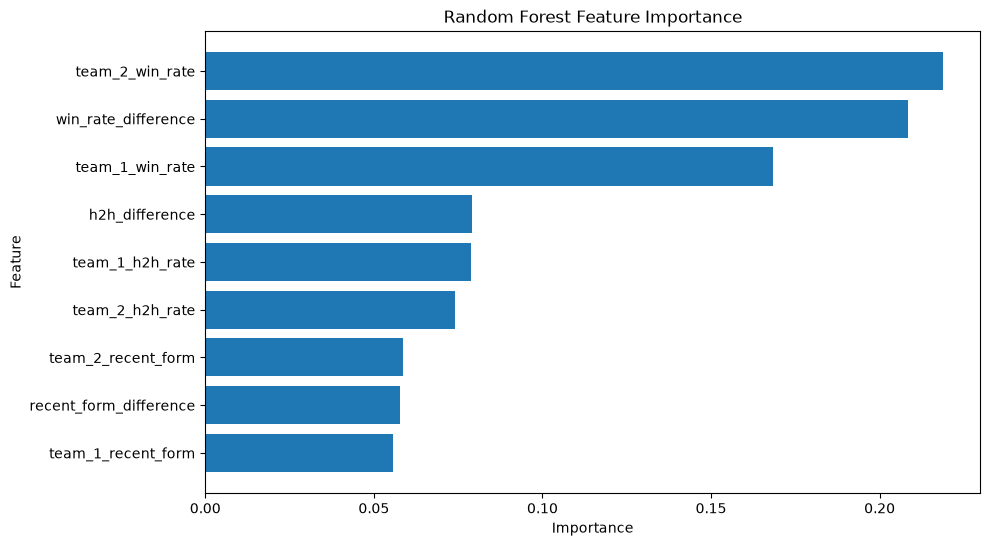

In [ ]:

# ============================================
# FEATURE IMPORTANCE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = final_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance_df)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
# ============================================
# COMPARE MULTIPLE ML MODELS
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Accuracy (%)": accuracy * 100
    })

    print(f"{name} Accuracy: {accuracy * 100:.2f}%")

results_df = pd.DataFrame(results)

print("\n================================")
print("MODEL COMPARISON")
print("================================")

display(
    results_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)


Training Logistic Regression...
Logistic Regression Accuracy: 55.33%

Training Random Forest...
Random Forest Accuracy: 45.90%

Training Gradient Boosting...
Gradient Boosting Accuracy: 50.00%

MODEL COMPARISON


,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.553279,55.327869
2,Gradient Boosting,0.500000,50.000000
1,Random Forest,0.459016,45.901639


In [ ]:
# ============================================
# STEP 1: VALIDATE FINAL FEATURES
# ============================================

feature_columns = [
    'team_1_win_rate',
    'team_2_win_rate',
    'win_rate_difference',
    'team_1_h2h_rate',
    'team_2_h2h_rate',
    'h2h_difference',
    'team_1_recent_form',
    'team_2_recent_form',
    'recent_form_difference'
]

print("Checking final features...")
print("=" * 50)

# Check that all features exist
print("\nFeature columns:")
print(feature_columns)

# Check missing values
print("\nMissing values:")
print(final_model_df[feature_columns].isnull().sum())

# Check infinite values
print("\nInfinite values:")
print(np.isinf(final_model_df[feature_columns]).sum())

# Check feature ranges
print("\nFeature statistics:")
display(final_model_df[feature_columns].describe())

print("\nFeature validation completed!")

Checking final features...

Feature columns:
['team_1_win_rate', 'team_2_win_rate', 'win_rate_difference', 'team_1_h2h_rate', 'team_2_h2h_rate', 'h2h_difference', 'team_1_recent_form', 'team_2_recent_form', 'recent_form_difference']

Missing values:


NameError: name 'final_model_df' is not defined

In [ ]:
# Find the dataframe containing all 9 final features

required_features = {
    'team_1_win_rate',
    'team_2_win_rate',
    'win_rate_difference',
    'team_1_h2h_rate',
    'team_2_h2h_rate',
    'h2h_difference',
    'team_1_recent_form',
    'team_2_recent_form',
    'recent_form_difference'
}

found_dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if required_features.issubset(set(obj.columns)):
            found_dataframes.append((name, obj.shape))

print("Dataframes containing all 9 final features:")
print("=" * 50)

for name, shape in found_dataframes:
    print(name, "→", shape)

Dataframes containing all 9 final features:
df → (1218, 18)
X → (1218, 9)
X_train → (974, 9)
X_test → (244, 9)
model_df → (1218, 18)


In [ ]:
# ============================================
# STEP 1B: VALIDATE FINAL FEATURES
# ============================================

feature_columns = [
    'team_1_win_rate',
    'team_2_win_rate',
    'win_rate_difference',
    'team_1_h2h_rate',
    'team_2_h2h_rate',
    'h2h_difference',
    'team_1_recent_form',
    'team_2_recent_form',
    'recent_form_difference'
]

print("FINAL FEATURE VALIDATION")
print("=" * 50)

# 1. Check missing values
print("\n1. Missing values:")
print(model_df[feature_columns].isnull().sum())

# 2. Check infinite values
print("\n2. Infinite values:")
print(np.isinf(model_df[feature_columns]).sum())

# 3. Check data types
print("\n3. Data types:")
print(model_df[feature_columns].dtypes)

# 4. Check feature statistics
print("\n4. Feature statistics:")
display(model_df[feature_columns].describe())

# 5. Check dataset shape
print("\n5. Dataset shape:")
print(model_df.shape)

print("\n" + "=" * 50)
print("FEATURE VALIDATION COMPLETED!")

FINAL FEATURE VALIDATION

1. Missing values:
team_1_win_rate           0
team_2_win_rate           0
win_rate_difference       0
team_1_h2h_rate           0
team_2_h2h_rate           0
h2h_difference            0
team_1_recent_form        0
team_2_recent_form        0
recent_form_difference    0
dtype: int64

2. Infinite values:
team_1_win_rate           0
team_2_win_rate           0
win_rate_difference       0
team_1_h2h_rate           0
team_2_h2h_rate           0
h2h_difference            0
team_1_recent_form        0
team_2_recent_form        0
recent_form_difference    0
dtype: int64

3. Data types:
team_1_win_rate           float64
team_2_win_rate           float64
win_rate_difference       float64
team_1_h2h_rate           float64
team_2_h2h_rate           float64
h2h_difference            float64
team_1_recent_form        float64
team_2_recent_form        float64
recent_form_difference    float64
dtype: object

4. Feature statistics:


,team_1_win_rate,team_2_win_rate,win_rate_difference,team_1_h2h_rate,team_2_h2h_rate,h2h_difference,team_1_recent_form,team_2_recent_form,recent_form_difference
count,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000
mean,0.517292,0.515260,0.002032,0.503570,0.496430,0.007141,0.505665,0.496743,0.008922
std,0.102001,0.104108,0.146238,0.217608,0.217608,0.435216,0.226644,0.228571,0.330837
min,0.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000
25%,0.474619,0.468870,-0.068058,0.400000,0.400000,-0.200000,0.400000,0.400000,-0.200000
50%,0.513987,0.512876,0.000000,0.500000,0.500000,0.000000,0.600000,0.400000,0.000000
75%,0.568627,0.566768,0.074442,0.600000,0.600000,0.200000,0.600000,0.600000,0.200000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



5. Dataset shape:
(1218, 18)

FEATURE VALIDATION COMPLETED!


In [ ]:
# ============================================
# STEP 2: FINAL MODEL TRAINING & COMPARISON
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Preparing final model data...")
print("=" * 60)

# Final features
feature_columns = [
    'team_1_win_rate',
    'team_2_win_rate',
    'win_rate_difference',
    'team_1_h2h_rate',
    'team_2_h2h_rate',
    'h2h_difference',
    'team_1_recent_form',
    'team_2_recent_form',
    'recent_form_difference'
]

# X and y
X_final = model_df[feature_columns]
y_final = model_df['target']

# Make sure data is sorted by date
model_df_sorted = model_df.sort_values('date').reset_index(drop=True)

X_final = model_df_sorted[feature_columns]
y_final = model_df_sorted['target']

# Date-based split: 80% training, 20% testing
split_index = int(len(model_df_sorted) * 0.8)

X_train_final = X_final.iloc[:split_index]
X_test_final = X_final.iloc[split_index:]

y_train_final = y_final.iloc[:split_index]
y_test_final = y_final.iloc[split_index:]

print("Training data:", X_train_final.shape)
print("Testing data:", X_test_final.shape)

print("\nTraining period:")
print(model_df_sorted['date'].iloc[0], "to",
      model_df_sorted['date'].iloc[split_index - 1])

print("\nTesting period:")
print(model_df_sorted['date'].iloc[split_index], "to",
      model_df_sorted['date'].iloc[-1])

# ============================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================

print("\n" + "=" * 60)
print("Training Logistic Regression...")

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_final, y_train_final)

logistic_predictions = logistic_model.predict(X_test_final)

logistic_accuracy = accuracy_score(
    y_test_final,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

print("Logistic Regression Accuracy (%):",
      logistic_accuracy * 100)

# ============================================
# MODEL 2: RANDOM FOREST
# ============================================

print("\n" + "=" * 60)
print("Training Random Forest...")

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=5
)

random_forest_model.fit(
    X_train_final,
    y_train_final
)

random_forest_predictions = random_forest_model.predict(
    X_test_final
)

random_forest_accuracy = accuracy_score(
    y_test_final,
    random_forest_predictions
)

print("Random Forest Accuracy:",
      random_forest_accuracy)

print("Random Forest Accuracy (%):",
      random_forest_accuracy * 100)

# ============================================
# MODEL 3: GRADIENT BOOSTING
# ============================================

print("\n" + "=" * 60)
print("Training Gradient Boosting...")

gradient_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(
    X_train_final,
    y_train_final
)

gradient_predictions = gradient_model.predict(
    X_test_final
)

gradient_accuracy = accuracy_score(
    y_test_final,
    gradient_predictions
)

print("Gradient Boosting Accuracy:",
      gradient_accuracy)

print("Gradient Boosting Accuracy (%):",
      gradient_accuracy * 100)

# ============================================
# FINAL COMPARISON
# ============================================

print("\n")
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

print(
    f"Logistic Regression : {logistic_accuracy * 100:.2f}%"
)

print(
    f"Random Forest       : {random_forest_accuracy * 100:.2f}%"
)

print(
    f"Gradient Boosting   : {gradient_accuracy * 100:.2f}%"
)

# Find best model
accuracies = {
    "Logistic Regression": logistic_accuracy,
    "Random Forest": random_forest_accuracy,
    "Gradient Boosting": gradient_accuracy
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

best_accuracy = accuracies[best_model_name]

print("\nBEST MODEL:")
print(best_model_name)

print(
    f"Best Accuracy: {best_accuracy * 100:.2f}%"
)

print("\nFinal model training completed!")

Preparing final model data...
Training data: (974, 9)
Testing data: (244, 9)

Training period:
2008-04-18 to 2023-04-30

Testing period:
2023-05-01 to 2026-05-31

Training Logistic Regression...
Logistic Regression Accuracy: 0.5491803278688525
Logistic Regression Accuracy (%): 54.91803278688525

Training Random Forest...
Random Forest Accuracy: 0.4672131147540984
Random Forest Accuracy (%): 46.72131147540984

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.5245901639344263
Gradient Boosting Accuracy (%): 52.459016393442624


FINAL MODEL COMPARISON
Logistic Regression : 54.92%
Random Forest       : 46.72%
Gradient Boosting   : 52.46%

BEST MODEL:
Logistic Regression
Best Accuracy: 54.92%

Final model training completed!


In [ ]:
# ============================================
# STEP 3: FINAL MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("=" * 60)
print("FINAL LOGISTIC REGRESSION EVALUATION")
print("=" * 60)

# Predictions
final_predictions = logistic_model.predict(X_test_final)

# Accuracy
final_accuracy = accuracy_score(
    y_test_final,
    final_predictions
)

print("\nFinal Accuracy:")
print(f"{final_accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(
    y_test_final,
    final_predictions
)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_final,
        final_predictions,
        target_names=[
            "Team 1 Wins",
            "Team 2 Wins"
        ]
    )
)

print("=" * 60)
print("FINAL EVALUATION COMPLETED!")
print("=" * 60)

FINAL LOGISTIC REGRESSION EVALUATION

Final Accuracy:
54.92%

Confusion Matrix:
[[  1 110]
 [  0 133]]

Classification Report:
              precision    recall  f1-score   support

 Team 1 Wins       1.00      0.01      0.02       111
 Team 2 Wins       0.55      1.00      0.71       133

    accuracy                           0.55       244
   macro avg       0.77      0.50      0.36       244
weighted avg       0.75      0.55      0.39       244

FINAL EVALUATION COMPLETED!


In [ ]:
print("TARGET DISTRIBUTION")
print(y_train.value_counts())
print()
print(y_test.value_counts())

print("\nPREDICTION DISTRIBUTION")
print(final_predictions if 'final_predictions' in globals() else "final_predictions not found")

print("\nLOGISTIC REGRESSION COEFFICIENTS")
for feature, coefficient in zip(feature_columns, final_logistic.coef_[0]):
    print(f"{feature}: {coefficient:.4f}")

TARGET DISTRIBUTION
target
1    533
0    441
Name: count, dtype: int64

target
1    133
0    111
Name: count, dtype: int64

PREDICTION DISTRIBUTION
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

LOGISTIC REGRESSION COEFFICIENTS


NameError: name 'final_logistic' is not defined

In [ ]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Everything is working!")

Pandas version: 3.0.5
NumPy version: 2.5.2
Everything is working!


In [ ]:
import json
from pathlib import Path

# Path to your IPL JSON files
data_folder = Path("../data/raw/ipl_json")

# Find all JSON files
json_files = sorted(data_folder.glob("*.json"))

print("Number of JSON files:", len(json_files))

# Show first 5 files
for file in json_files[:5]:
    print(file)

Number of JSON files: 1243
..\data\raw\ipl_json\1082591.json
..\data\raw\ipl_json\1082592.json
..\data\raw\ipl_json\1082593.json
..\data\raw\ipl_json\1082594.json
..\data\raw\ipl_json\1082595.json


In [ ]:
print("FINAL DATASET CHECK")
print("=" * 50)

print("Dataset shape:", model_df.shape)

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget distribution:")
print(model_df["target"].value_counts())

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nEverything is ready for the next modeling step.")

FINAL DATASET CHECK


NameError: name 'model_df' is not defined

In [ ]:
model_df
target
final_logistic
recent_rf
combined_rf

NameError: name 'model_df' is not defined

In [ ]:
import sys
print(sys.executable)

c:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Everything is working!")


Pandas: 3.0.5
NumPy: 2.5.2
Everything is working!


In [ ]:
import os
import glob

json_folder = "../data/raw/ipl_json"

json_files = glob.glob(os.path.join(json_folder, "*.json"))

print("Number of JSON files:", len(json_files))

print("\nFirst 5 JSON files:")
for file in json_files[:5]:
    print(file)

Number of JSON files: 1243

First 5 JSON files:
../data/raw/ipl_json\1082591.json
../data/raw/ipl_json\1082592.json
../data/raw/ipl_json\1082593.json
../data/raw/ipl_json\1082594.json
../data/raw/ipl_json\1082595.json


In [ ]:
print("================================")
print("KERNEL TEST")
print("================================")

import sys
import pandas as pd
import numpy as np

print("Python:")
print(sys.executable)

print("\nPandas:", pd.__version__)
print("NumPy:", np.__version__)

print("\nKERNEL IS WORKING!")

KERNEL TEST
Python:
c:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\Scripts\python.exe

Pandas: 3.0.5
NumPy: 2.5.2

KERNEL IS WORKING!


In [1]:
import glob
import os

print("Current working directory:")
print(os.getcwd())

json_files = glob.glob("../data/raw/ipl_json/*.json")

print("\nNumber of JSON files:", len(json_files))

print("\nFirst 5 JSON files:")
for file in json_files[:5]:
    print(file)

Current working directory:
c:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\notebooks

Number of JSON files: 1243

First 5 JSON files:
../data/raw/ipl_json\1082591.json
../data/raw/ipl_json\1082592.json
../data/raw/ipl_json\1082593.json
../data/raw/ipl_json\1082594.json
../data/raw/ipl_json\1082595.json


In [2]:
import glob
import os

print("Current working directory:")
print(os.getcwd())

json_files = glob.glob("../data/raw/ipl_json/*.json")

print("\nNumber of JSON files:", len(json_files))

print("\nFirst 5 JSON files:")
for file in json_files[:5]:
    print(file)

Current working directory:
c:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\notebooks

Number of JSON files: 1243

First 5 JSON files:
../data/raw/ipl_json\1082591.json
../data/raw/ipl_json\1082592.json
../data/raw/ipl_json\1082593.json
../data/raw/ipl_json\1082594.json
../data/raw/ipl_json\1082595.json


In [4]:
import json
import pandas as pd

matches = []

for file in json_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    info = data["info"]

    matches.append({
        "season": info.get("season"),
        "date": info.get("dates", [None])[0],
        "team_1": info["teams"][0],
        "team_2": info["teams"][1],
        "winner": info.get("outcome", {}).get("winner"),
        "json_file": file
    })

df = pd.DataFrame(matches)

print("Dataset created successfully!")
print("Shape:", df.shape)

print("\nFirst 5 matches:")
display(df.head())

Dataset created successfully!
Shape: (1243, 6)

First 5 matches:


,season,date,team_1,team_2,winner,json_file
0,2017,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,../data/raw/ipl_json\1082591.json
1,2017,2017-04-06,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,../data/raw/ipl_json\1082592.json
2,2017,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,../data/raw/ipl_json\1082593.json
3,2017,2017-04-08,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,../data/raw/ipl_json\1082594.json
4,2017,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,../data/raw/ipl_json\1082595.json


In [5]:
def get_innings_score(innings):
    total_runs = 0

    for over in innings.get("overs", []):
        for delivery in over.get("deliveries", []):
            total_runs += delivery.get("runs", {}).get("total", 0)

    return total_runs


team1_scores = []
team2_scores = []

for file in df["json_file"]:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    innings = data.get("innings", [])

    scores = {}

    for inning in innings:
        team = inning.get("team")
        scores[team] = get_innings_score(inning)

    teams = data["info"]["teams"]

    team1_scores.append(scores.get(teams[0], None))
    team2_scores.append(scores.get(teams[1], None))


df["team_1_score"] = team1_scores
df["team_2_score"] = team2_scores

print("Scores added successfully!")

print("\nDataset shape:", df.shape)

print("\nFirst 5 matches with scores:")
display(
    df[
        [
            "season",
            "date",
            "team_1",
            "team_1_score",
            "team_2",
            "team_2_score",
            "winner"
        ]
    ].head()
)

Scores added successfully!

Dataset shape: (1243, 8)

First 5 matches with scores:


,season,date,team_1,team_1_score,team_2,team_2_score,winner
0,2017,2017-04-05,Sunrisers Hyderabad,207,Royal Challengers Bangalore,172.0,Sunrisers Hyderabad
1,2017,2017-04-06,Rising Pune Supergiant,187,Mumbai Indians,184.0,Rising Pune Supergiant
2,2017,2017-04-07,Gujarat Lions,183,Kolkata Knight Riders,184.0,Kolkata Knight Riders
3,2017,2017-04-08,Kings XI Punjab,164,Rising Pune Supergiant,163.0,Kings XI Punjab
4,2017,2017-04-08,Royal Challengers Bangalore,157,Delhi Daredevils,142.0,Royal Challengers Bangalore


In [6]:
print("BEFORE REMOVING NO RESULT MATCHES")
print("Total matches:", len(df))

# Find matches without a winner
no_result_matches = df[df["winner"].isna()]

print("\nNo Result / Missing Winner matches:", len(no_result_matches))

if len(no_result_matches) > 0:
    print("\nExamples:")
    display(
        no_result_matches[
            [
                "season",
                "date",
                "team_1",
                "team_2",
                "team_1_score",
                "team_2_score",
                "winner"
            ]
        ].head(10)
    )

# Remove matches without a winner
df = df[df["winner"].notna()].copy()

# Reset index
df.reset_index(drop=True, inplace=True)

print("\nAFTER REMOVING NO RESULT MATCHES")
print("Total matches:", len(df))
print("Missing winners:", df["winner"].isna().sum())

BEFORE REMOVING NO RESULT MATCHES
Total matches: 1243

No Result / Missing Winner matches: 25

Examples:


,season,date,team_1,team_2,team_1_score,team_2_score,winner
33,2017,2017-04-29,Gujarat Lions,Mumbai Indians,6,11.0,NaN
128,2019,2019-03-30,Kolkata Knight Riders,Delhi Capitals,7,10.0,NaN
167,2019,2019-04-30,Royal Challengers Bangalore,Rajasthan Royals,62,41.0,NaN
169,2019,2019-05-02,Mumbai Indians,Sunrisers Hyderabad,9,8.0,NaN
180,2020/21,2020-09-20,Delhi Capitals,Kings XI Punjab,3,2.0,NaN
199,2020/21,2020-10-18,Kolkata Knight Riders,Sunrisers Hyderabad,3,2.0,NaN
204,2020/21,2020-10-18,Mumbai Indians,Kings XI Punjab,11,15.0,NaN
234,2020/21,2020-09-28,Royal Challengers Bangalore,Mumbai Indians,11,7.0,NaN
258,2021,2021-04-25,Delhi Capitals,Sunrisers Hyderabad,8,7.0,NaN
417,2023,2023-05-03,Lucknow Super Giants,Chennai Super Kings,125,NaN,NaN



AFTER REMOVING NO RESULT MATCHES
Total matches: 1218
Missing winners: 0


In [7]:
# Create prediction target

df["target"] = (df["winner"] != df["team_1"]).astype(int)

print("Target created successfully!")

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget meaning:")
print("0 = Team 1 wins")
print("1 = Team 2 wins")

print("\nFirst 10 matches:")
display(
    df[
        [
            "season",
            "date",
            "team_1",
            "team_2",
            "winner",
            "target"
        ]
    ].head(10)
)

Target created successfully!

Target distribution:
target
1    610
0    608
Name: count, dtype: int64

Target meaning:
0 = Team 1 wins
1 = Team 2 wins

First 10 matches:


,season,date,team_1,team_2,winner,target
0,2017,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,0
1,2017,2017-04-06,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,0
2,2017,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,1
3,2017,2017-04-08,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,0
4,2017,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,0
5,2017,2017-04-09,Sunrisers Hyderabad,Gujarat Lions,Sunrisers Hyderabad,0
6,2017,2017-04-09,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,0
7,2017,2017-04-10,Kings XI Punjab,Royal Challengers Bangalore,Kings XI Punjab,0
8,2017,2017-04-11,Rising Pune Supergiant,Delhi Daredevils,Delhi Daredevils,1
9,2017,2017-04-12,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,0


In [8]:
# ============================================
# CREATE HISTORICAL TEAM WIN-RATE FEATURES
# ============================================

team_stats = {}

team1_win_rate = []
team2_win_rate = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Get previous statistics
    stats1 = team_stats.get(team1, {"wins": 0, "matches": 0})
    stats2 = team_stats.get(team2, {"wins": 0, "matches": 0})

    # Calculate win rates BEFORE this match
    if stats1["matches"] > 0:
        rate1 = stats1["wins"] / stats1["matches"]
    else:
        rate1 = 0.5

    if stats2["matches"] > 0:
        rate2 = stats2["wins"] / stats2["matches"]
    else:
        rate2 = 0.5

    team1_win_rate.append(rate1)
    team2_win_rate.append(rate2)

    # Update statistics AFTER the match
    if team1 not in team_stats:
        team_stats[team1] = {"wins": 0, "matches": 0}

    if team2 not in team_stats:
        team_stats[team2] = {"wins": 0, "matches": 0}

    team_stats[team1]["matches"] += 1
    team_stats[team2]["matches"] += 1

    if row["winner"] == team1:
        team_stats[team1]["wins"] += 1
    elif row["winner"] == team2:
        team_stats[team2]["wins"] += 1


# Add features to dataframe
df["team_1_win_rate"] = team1_win_rate
df["team_2_win_rate"] = team2_win_rate

df["win_rate_difference"] = (
    df["team_1_win_rate"] - df["team_2_win_rate"]
)

print("Historical features created successfully!")

print("\nDataset shape:", df.shape)

print("\nNew features:")
print("team_1_win_rate")
print("team_2_win_rate")
print("win_rate_difference")

print("\nFirst 10 matches:")
display(
    df[
        [
            "season",
            "team_1",
            "team_2",
            "winner",
            "target",
            "team_1_win_rate",
            "team_2_win_rate",
            "win_rate_difference"
        ]
    ].head(10)
)

Historical features created successfully!

Dataset shape: (1218, 12)

New features:
team_1_win_rate
team_2_win_rate
win_rate_difference

First 10 matches:


,season,team_1,team_2,winner,target,team_1_win_rate,team_2_win_rate,win_rate_difference
0,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,0,0.5,0.5,0.0
1,2017,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,0,0.5,0.5,0.0
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,1,0.5,0.5,0.0
3,2017,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,0,0.5,1.0,-0.5
4,2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,0,0.0,0.5,-0.5
5,2017,Sunrisers Hyderabad,Gujarat Lions,Sunrisers Hyderabad,0,1.0,0.0,1.0
6,2017,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,0,0.0,1.0,-1.0
7,2017,Kings XI Punjab,Royal Challengers Bangalore,Kings XI Punjab,0,1.0,0.5,0.5
8,2017,Rising Pune Supergiant,Delhi Daredevils,Delhi Daredevils,1,0.5,0.0,0.5
9,2017,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,0,0.5,1.0,-0.5


In [9]:
# ============================================
# CREATE FINAL FEATURES FOR MACHINE LEARNING
# ============================================

features = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference"
]

X = df[features].copy()
y = df["target"].copy()

print("Features and target created successfully!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nFirst 10 feature rows:")
display(X.head(10))

print("\nFirst 10 target values:")
display(y.head(10))

print("\nMissing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

Features and target created successfully!

X shape: (1218, 3)
y shape: (1218,)

Features used:
- team_1_win_rate
- team_2_win_rate
- win_rate_difference

First 10 feature rows:


,team_1_win_rate,team_2_win_rate,win_rate_difference
0,0.5,0.5,0.0
1,0.5,0.5,0.0
2,0.5,0.5,0.0
3,0.5,1.0,-0.5
4,0.0,0.5,-0.5
5,1.0,0.0,1.0
6,0.0,1.0,-1.0
7,1.0,0.5,0.5
8,0.5,0.0,0.5
9,0.5,1.0,-0.5



First 10 target values:


0    0
1    0
2    1
3    0
4    0
5    0
6    0
7    0
8    1
9    0
Name: target, dtype: int64


Missing values in X:
team_1_win_rate        0
team_2_win_rate        0
win_rate_difference    0
dtype: int64

Missing values in y:
0


In [10]:
# ============================================
# TIME-BASED TRAIN / TEST SPLIT
# ============================================

# Use the first 80% of matches for training
# Use the last 20% of matches for testing

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Data split successfully!")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining matches:")
print(split_index)

print("\nTesting matches:")
print(len(df) - split_index)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining period:")
print(df.iloc[0]["date"], "to", df.iloc[split_index - 1]["date"])

print("\nTesting period:")
print(df.iloc[split_index]["date"], "to", df.iloc[-1]["date"])

Data split successfully!

Training data:
X_train shape: (974, 3)
y_train shape: (974,)

Testing data:
X_test shape: (244, 3)
y_test shape: (244,)

Training matches:
974

Testing matches:
244

Training target distribution:
target
1    502
0    472
Name: count, dtype: int64

Testing target distribution:
target
0    136
1    108
Name: count, dtype: int64

Training period:
2017-04-05 to 2013-04-06

Testing period:
2013-04-07 to 2016-05-29


In [11]:
# ============================================
# CHECK DATE ORDER
# ============================================

print("First 5 dates:")
print(df["date"].head())

print("\nLast 5 dates:")
print(df["date"].tail())

print("\nDate data type:")
print(df["date"].dtype)

print("\nMinimum date:")
print(df["date"].min())

print("\nMaximum date:")
print(df["date"].max())

First 5 dates:
0    2017-04-05
1    2017-04-06
2    2017-04-07
3    2017-04-08
4    2017-04-08
Name: date, dtype: str

Last 5 dates:
1213    2016-05-22
1214    2016-05-24
1215    2016-05-25
1216    2016-05-27
1217    2016-05-29
Name: date, dtype: str

Date data type:
str

Minimum date:
2008-04-18

Maximum date:
2026-05-31


In [12]:
# ============================================
# SORT DATASET CHRONOLOGICALLY
# ============================================

# Convert date from string to proper datetime
df["date"] = pd.to_datetime(df["date"])

# Sort matches from oldest to newest
df = df.sort_values("date").reset_index(drop=True)

print("Dataset sorted chronologically!")

print("\nFirst 5 matches:")
display(
    df[
        [
            "date",
            "season",
            "team_1",
            "team_2",
            "winner"
        ]
    ].head()
)

print("\nLast 5 matches:")
display(
    df[
        [
            "date",
            "season",
            "team_1",
            "team_2",
            "winner"
        ]
    ].tail()
)

print("\nDate data type:")
print(df["date"].dtype)

print("\nMinimum date:")
print(df["date"].min())

print("\nMaximum date:")
print(df["date"].max())

Dataset sorted chronologically!

First 5 matches:


,date,season,team_1,team_2,winner
0,2008-04-18,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,2008-04-19,2007/08,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings
2,2008-04-19,2007/08,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils
3,2008-04-20,2007/08,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders
4,2008-04-20,2007/08,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore



Last 5 matches:


,date,season,team_1,team_2,winner
1213,2026-05-24,2026,Delhi Capitals,Kolkata Knight Riders,Delhi Capitals
1214,2026-05-26,2026,Royal Challengers Bengaluru,Gujarat Titans,Royal Challengers Bengaluru
1215,2026-05-27,2026,Rajasthan Royals,Sunrisers Hyderabad,Rajasthan Royals
1216,2026-05-29,2026,Rajasthan Royals,Gujarat Titans,Gujarat Titans
1217,2026-05-31,2026,Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru



Date data type:
datetime64[us]

Minimum date:
2008-04-18 00:00:00

Maximum date:
2026-05-31 00:00:00


In [13]:
# ============================================
# RECALCULATE HISTORICAL WIN-RATE FEATURES
# AFTER CHRONOLOGICAL SORTING
# ============================================

team_stats = {}

team1_win_rate = []
team2_win_rate = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Get statistics BEFORE this match
    stats1 = team_stats.get(
        team1,
        {"wins": 0, "matches": 0}
    )

    stats2 = team_stats.get(
        team2,
        {"wins": 0, "matches": 0}
    )

    # Calculate historical win rates
    if stats1["matches"] > 0:
        rate1 = stats1["wins"] / stats1["matches"]
    else:
        rate1 = 0.5

    if stats2["matches"] > 0:
        rate2 = stats2["wins"] / stats2["matches"]
    else:
        rate2 = 0.5

    team1_win_rate.append(rate1)
    team2_win_rate.append(rate2)

    # Initialize teams if necessary
    if team1 not in team_stats:
        team_stats[team1] = {
            "wins": 0,
            "matches": 0
        }

    if team2 not in team_stats:
        team_stats[team2] = {
            "wins": 0,
            "matches": 0
        }

    # Update matches AFTER the match
    team_stats[team1]["matches"] += 1
    team_stats[team2]["matches"] += 1

    # Update winner AFTER the match
    if row["winner"] == team1:
        team_stats[team1]["wins"] += 1

    elif row["winner"] == team2:
        team_stats[team2]["wins"] += 1


# Add historical features
df["team_1_win_rate"] = team1_win_rate
df["team_2_win_rate"] = team2_win_rate

df["win_rate_difference"] = (
    df["team_1_win_rate"]
    - df["team_2_win_rate"]
)

print("Historical features recalculated successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 10 matches:")

display(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "target",
            "team_1_win_rate",
            "team_2_win_rate",
            "win_rate_difference"
        ]
    ].head(10)
)

print("\nMissing values:")

print(
    df[
        [
            "team_1_win_rate",
            "team_2_win_rate",
            "win_rate_difference",
            "target"
        ]
    ].isnull().sum()
)

Historical features recalculated successfully!

Dataset shape:
(1218, 12)

First 10 matches:


,date,team_1,team_2,winner,target,team_1_win_rate,team_2_win_rate,win_rate_difference
0,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,1,0.5,0.5,0.0
1,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,1,0.5,0.5,0.0
2,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0,0.5,0.5,0.0
3,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0,1.0,0.5,0.5
4,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,1,0.5,0.0,0.5
5,2008-04-21,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0,0.0,0.0,0.0
6,2008-04-22,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,1,0.0,1.0,-1.0
7,2008-04-23,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,0,1.0,0.0,1.0
8,2008-04-24,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,1,0.0,0.5,-0.5
9,2008-04-25,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,0,0.0,0.0,0.0



Missing values:
team_1_win_rate        0
team_2_win_rate        0
win_rate_difference    0
target                 0
dtype: int64


In [14]:
# ============================================
# CREATE FEATURES (X) AND TARGET (y)
# ============================================

features = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference"
]

X = df[features]
y = df["target"]

print("Features and target created successfully!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nFirst 5 feature rows:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Features and target created successfully!

X shape: (1218, 3)
y shape: (1218,)

Features used:
- team_1_win_rate
- team_2_win_rate
- win_rate_difference

First 5 feature rows:


,team_1_win_rate,team_2_win_rate,win_rate_difference
0,0.5,0.5,0.0
1,0.5,0.5,0.0
2,0.5,0.5,0.0
3,1.0,0.5,0.5
4,0.5,0.0,0.5



First 5 target values:


0    1
1    1
2    0
3    0
4    1
Name: target, dtype: int64


Missing values in X:
team_1_win_rate        0
team_2_win_rate        0
win_rate_difference    0
dtype: int64

Missing values in y:
0


In [15]:
# ============================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================

split_index = int(len(df) * 0.80)

# Training data = oldest 80%
X_train = X.iloc[:split_index].copy()
y_train = y.iloc[:split_index].copy()

# Testing data = newest 20%
X_test = X.iloc[split_index:].copy()
y_test = y.iloc[split_index:].copy()

print("Data split successfully!")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining matches:")
print(len(X_train))

print("\nTesting matches:")
print(len(X_test))

print("\nTraining period:")
print(
    df.iloc[:split_index]["date"].min().date(),
    "to",
    df.iloc[:split_index]["date"].max().date()
)

print("\nTesting period:")
print(
    df.iloc[split_index:]["date"].min().date(),
    "to",
    df.iloc[split_index:]["date"].max().date()
)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Data split successfully!

Training data:
X_train shape: (974, 3)
y_train shape: (974,)

Testing data:
X_test shape: (244, 3)
y_test shape: (244,)

Training matches:
974

Testing matches:
244

Training period:
2008-04-18 to 2023-04-30

Testing period:
2023-05-01 to 2026-05-31

Training target distribution:
target
0    497
1    477
Name: count, dtype: int64

Testing target distribution:
target
1    133
0    111
Name: count, dtype: int64


In [16]:
# ============================================
# TRAIN LOGISTIC REGRESSION MODEL
# ============================================

from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(random_state=42)

# Train the model using only training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
# ============================================
# STEP 7: MAKE PREDICTIONS
# ============================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on TEST data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions created successfully!")

print("\nNumber of predictions:", len(y_pred))

print("\nAccuracy:")
print(f"{accuracy:.4f}")

print(f"\nAccuracy percentage: {accuracy * 100:.2f}%")

# Show first 20 actual vs predicted results
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nFirst 20 predictions:")
display(results.head(20))

Predictions created successfully!

Number of predictions: 244

Accuracy:
0.4713

Accuracy percentage: 47.13%

First 20 predictions:


,Actual,Predicted
0,0,1
1,0,1
2,1,1
3,0,0
4,1,1
5,1,0
6,1,0
7,0,0
8,1,0
9,1,0


In [18]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy percentage: {accuracy * 100:.2f}%")

Accuracy: 0.4713
Accuracy percentage: 47.13%


In [19]:
# ============================================
# STEP 8: MODEL EVALUATION
# ============================================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Team 1 Wins",
            "Team 2 Wins"
        ]
    )
)

Confusion Matrix:
[[ 86  25]
 [104  29]]

Classification Report:
              precision    recall  f1-score   support

 Team 1 Wins       0.45      0.77      0.57       111
 Team 2 Wins       0.54      0.22      0.31       133

    accuracy                           0.47       244
   macro avg       0.49      0.50      0.44       244
weighted avg       0.50      0.47      0.43       244



In [20]:
# ============================================
# STEP 9: CREATE RECENT FORM FEATURES
# ============================================

# Store each team's previous match results
team_recent_results = {}

team1_recent_win_rate = []
team2_recent_win_rate = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Get previous results
    results1 = team_recent_results.get(team1, [])
    results2 = team_recent_results.get(team2, [])

    # Use only the previous 5 matches
    last_5_team1 = results1[-5:]
    last_5_team2 = results2[-5:]

    # Calculate recent win rate
    if len(last_5_team1) > 0:
        recent_rate1 = sum(last_5_team1) / len(last_5_team1)
    else:
        recent_rate1 = 0.5

    if len(last_5_team2) > 0:
        recent_rate2 = sum(last_5_team2) / len(last_5_team2)
    else:
        recent_rate2 = 0.5

    team1_recent_win_rate.append(recent_rate1)
    team2_recent_win_rate.append(recent_rate2)

    # Initialize teams if needed
    if team1 not in team_recent_results:
        team_recent_results[team1] = []

    if team2 not in team_recent_results:
        team_recent_results[team2] = []

    # Record current match result AFTER calculating features
    if row["winner"] == team1:
        team_recent_results[team1].append(1)
        team_recent_results[team2].append(0)

    elif row["winner"] == team2:
        team_recent_results[team1].append(0)
        team_recent_results[team2].append(1)


# Add features to dataframe
df["team_1_recent_win_rate"] = team1_recent_win_rate
df["team_2_recent_win_rate"] = team2_recent_win_rate

df["recent_form_difference"] = (
    df["team_1_recent_win_rate"]
    - df["team_2_recent_win_rate"]
)

print("Recent form features created successfully!")

print("\nDataset shape:", df.shape)

print("\nNew features:")
print("team_1_recent_win_rate")
print("team_2_recent_win_rate")
print("recent_form_difference")

print("\nFirst 10 matches:")
display(
    df[
        [
            "season",
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_recent_win_rate",
            "team_2_recent_win_rate",
            "recent_form_difference"
        ]
    ].head(10)
)

Recent form features created successfully!

Dataset shape: (1218, 15)

New features:
team_1_recent_win_rate
team_2_recent_win_rate
recent_form_difference

First 10 matches:


,season,date,team_1,team_2,winner,team_1_recent_win_rate,team_2_recent_win_rate,recent_form_difference
0,2007/08,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,0.5,0.5,0.0
1,2007/08,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,0.5,0.5,0.0
2,2007/08,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0.5,0.5,0.0
3,2007/08,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,1.0,0.5,0.5
4,2007/08,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0.5,0.0,0.5
5,2007/08,2008-04-21,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0.0,0.0,0.0
6,2007/08,2008-04-22,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0.0,1.0,-1.0
7,2007/08,2008-04-23,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,1.0,0.0,1.0
8,2007/08,2008-04-24,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0.0,0.5,-0.5
9,2007/08,2008-04-25,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,0.0,0.0,0.0


In [21]:
# ============================================
# STEP 10: CREATE UPDATED FEATURES
# ============================================

features = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference",
    "team_1_recent_win_rate",
    "team_2_recent_win_rate",
    "recent_form_difference"
]

X = df[features]
y = df["target"]

print("Updated features and target created successfully!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Updated features and target created successfully!

X shape: (1218, 6)
y shape: (1218,)

Features used:
- team_1_win_rate
- team_2_win_rate
- win_rate_difference
- team_1_recent_win_rate
- team_2_recent_win_rate
- recent_form_difference

Missing values in X:
team_1_win_rate           0
team_2_win_rate           0
win_rate_difference       0
team_1_recent_win_rate    0
team_2_recent_win_rate    0
recent_form_difference    0
dtype: int64

Missing values in y:
0


In [22]:
# ============================================
# STEP 11: CHRONOLOGICAL TRAIN/TEST SPLIT
# ============================================

# Make sure data is sorted by date
df = df.sort_values("date").reset_index(drop=True)

# Recreate X and y after sorting
X = df[features]
y = df["target"]

# Calculate split point
split_index = int(len(df) * 0.80)

# Split chronologically
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data split successfully!")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining matches:")
print(len(X_train))

print("\nTesting matches:")
print(len(X_test))

print("\nTraining period:")
print(df["date"].iloc[0], "to", df["date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["date"].iloc[split_index], "to", df["date"].iloc[-1])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Data split successfully!

Training data:
X_train shape: (974, 6)
y_train shape: (974,)

Testing data:
X_test shape: (244, 6)
y_test shape: (244,)

Training matches:
974

Testing matches:
244

Training period:
2008-04-18 00:00:00 to 2023-04-30 00:00:00

Testing period:
2023-05-01 00:00:00 to 2026-05-31 00:00:00

Training target distribution:
target
0    497
1    477
Name: count, dtype: int64

Testing target distribution:
target
1    133
0    111
Name: count, dtype: int64


In [23]:
# ============================================
# STEP 12: TRAIN UPDATED LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Updated Logistic Regression model trained successfully!")

Updated Logistic Regression model trained successfully!


In [24]:
# ============================================
# STEP 13: MAKE PREDICTIONS
# ============================================

from sklearn.metrics import accuracy_score

# Predict winners for the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions created successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 actual values:")
print(y_test.iloc[:20].values)

print("\nNew Model Accuracy:")
print(f"{accuracy:.4f}")

print(f"Accuracy percentage: {accuracy * 100:.2f}%")

Predictions created successfully!

First 20 predictions:
[0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 1 0 0 0]

First 20 actual values:
[0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 0 1 0 0]

New Model Accuracy:
0.4918
Accuracy percentage: 49.18%


In [25]:
# ============================================
# STEP 14: CREATE HEAD-TO-HEAD FEATURES
# ============================================

# Store previous results between pairs of teams
head_to_head = {}

team1_h2h_win_rate = []
team2_h2h_win_rate = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Create a consistent matchup key
    matchup = tuple(sorted([team1, team2]))

    # Get previous results for this matchup
    previous_matches = head_to_head.get(matchup, [])

    # Calculate Team 1's previous win rate against Team 2
    if len(previous_matches) > 0:
        team1_previous_wins = sum(
            1 for winner in previous_matches
            if winner == team1
        )

        team2_previous_wins = sum(
            1 for winner in previous_matches
            if winner == team2
        )

        total_matches = len(previous_matches)

        h2h_rate1 = team1_previous_wins / total_matches
        h2h_rate2 = team2_previous_wins / total_matches

    else:
        # No previous head-to-head matches
        h2h_rate1 = 0.5
        h2h_rate2 = 0.5

    team1_h2h_win_rate.append(h2h_rate1)
    team2_h2h_win_rate.append(h2h_rate2)

    # Update head-to-head history AFTER the current match
    if matchup not in head_to_head:
        head_to_head[matchup] = []

    head_to_head[matchup].append(row["winner"])


# Add features to dataframe
df["team_1_h2h_win_rate"] = team1_h2h_win_rate
df["team_2_h2h_win_rate"] = team2_h2h_win_rate

df["h2h_difference"] = (
    df["team_1_h2h_win_rate"]
    - df["team_2_h2h_win_rate"]
)

print("Head-to-head features created successfully!")

print("\nDataset shape:", df.shape)

print("\nNew features:")
print("team_1_h2h_win_rate")
print("team_2_h2h_win_rate")
print("h2h_difference")

print("\nFirst 10 matches:")
display(
    df[
        [
            "season",
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_h2h_win_rate",
            "team_2_h2h_win_rate",
            "h2h_difference"
        ]
    ].head(10)
)

Head-to-head features created successfully!

Dataset shape: (1218, 18)

New features:
team_1_h2h_win_rate
team_2_h2h_win_rate
h2h_difference

First 10 matches:


,season,date,team_1,team_2,winner,team_1_h2h_win_rate,team_2_h2h_win_rate,h2h_difference
0,2007/08,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,0.5,0.5,0.0
1,2007/08,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,0.5,0.5,0.0
2,2007/08,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0.5,0.5,0.0
3,2007/08,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0.5,0.5,0.0
4,2007/08,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0.5,0.5,0.0
5,2007/08,2008-04-21,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0.5,0.5,0.0
6,2007/08,2008-04-22,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0.5,0.5,0.0
7,2007/08,2008-04-23,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,0.5,0.5,0.0
8,2007/08,2008-04-24,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0.5,0.5,0.0
9,2007/08,2008-04-25,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,0.5,0.5,0.0


In [26]:
# ============================================
# STEP 15: UPDATE FEATURES WITH HEAD-TO-HEAD
# ============================================

features = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference",
    "team_1_recent_win_rate",
    "team_2_recent_win_rate",
    "recent_form_difference",
    "team_1_h2h_win_rate",
    "team_2_h2h_win_rate",
    "h2h_difference"
]

X = df[features]
y = df["target"]

print("Updated features and target created successfully!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Updated features and target created successfully!

X shape: (1218, 9)
y shape: (1218,)

Features used:
- team_1_win_rate
- team_2_win_rate
- win_rate_difference
- team_1_recent_win_rate
- team_2_recent_win_rate
- recent_form_difference
- team_1_h2h_win_rate
- team_2_h2h_win_rate
- h2h_difference

Missing values in X:
team_1_win_rate           0
team_2_win_rate           0
win_rate_difference       0
team_1_recent_win_rate    0
team_2_recent_win_rate    0
recent_form_difference    0
team_1_h2h_win_rate       0
team_2_h2h_win_rate       0
h2h_difference            0
dtype: int64

Missing values in y:
0


In [1]:
# ============================================
# STEP 16: TIME-BASED TRAIN/TEST SPLIT
# ============================================

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Sort matches chronologically
df = df.sort_values("date").reset_index(drop=True)

# Re-create X and y
X = df[features]
y = df["target"]

# 80% training, 20% testing
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data split successfully!")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining matches:")
print(len(X_train))

print("\nTesting matches:")
print(len(X_test))

print("\nTraining period:")
print(df["date"].iloc[0], "to", df["date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["date"].iloc[split_index], "to", df["date"].iloc[-1])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Imports working!")

Pandas: 3.0.5
NumPy: 2.5.2
Imports working!


In [3]:
# ============================================
# CHECK BEFORE STEP 16
# ============================================

print("Pandas:", pd.__version__)
print("Dataset shape:", df.shape)

print("\nDate column type:")
print(df["date"].dtype)

print("\nNumber of features:", len(features))
print("\nFeatures:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Pandas: 3.0.5


NameError: name 'df' is not defined

In [4]:
import pandas as pd
import numpy as np

In [5]:
# ============================================
# CHECK BEFORE STEP 16
# ============================================

print("Pandas:", pd.__version__)
print("Dataset shape:", df.shape)

print("\nDate column type:")
print(df["date"].dtype)

print("\nNumber of features:", len(features))
print("\nFeatures:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Pandas: 3.0.5


NameError: name 'df' is not defined

In [6]:
import pandas as pd
import numpy as np
import json
import glob

In [7]:
import pandas as pd
import numpy as np
import json
import glob

In [8]:
import pandas as pd
import numpy as np
import json
import glob

In [9]:
# ============================================
# STEP 16: TIME-BASED TRAIN/TEST SPLIT
# ============================================

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by date
df = df.sort_values("date").reset_index(drop=True)

# Re-create X and y after sorting
X = df[features]
y = df["target"]

# Use 80% for training and 20% for testing
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data split successfully!")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining matches:")
print(len(X_train))

print("\nTesting matches:")
print(len(X_test))

print("\nTraining period:")
print(df["date"].iloc[0], "to", df["date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["date"].iloc[split_index], "to", df["date"].iloc[-1])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

NameError: name 'df' is not defined

In [10]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Imports working!")


Pandas: 3.0.5
NumPy: 2.5.2
Imports working!


In [11]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
c:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\notebooks

Files in this folder:
['.ipynb_checkpoints', '01_IPL_Data_Exploration.ipynb']


In [12]:
print("Pandas:", pd.__version__)
print("Dataset shape:", df.shape)

print("\nDate column type:")
print(df["date"].dtype)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(features)

Pandas: 3.0.5


NameError: name 'df' is not defined

In [13]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current folder:
c:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\notebooks

Files:
['.ipynb_checkpoints', '01_IPL_Data_Exploration.ipynb']


In [14]:
import os

project_folder = r"C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction"

print("Searching for dataset files...\n")

for root, dirs, files in os.walk(project_folder):
    for file in files:
        if file.lower().endswith((".csv", ".json", ".xlsx")):
            print(os.path.join(root, file))

Searching for dataset files...

C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\jupyter_notebook_config.d\jupyterlab.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\jupyter_server_config.d\jupyter-lsp-jupyter-server.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\jupyter_server_config.d\jupyterlab.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\jupyter_server_config.d\jupyter_server_terminals.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\jupyter_server_config.d\notebook.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\jupyter_server_config.d\notebook_shim.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\etc\jupyter\nbconfig\notebook.d\widgetsnbextension.json
C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\.venv\Lib\sit

In [15]:
# ============================================
# STEP 3: LOAD IPL JSON DATA
# ============================================

import os
import json
import pandas as pd

data_folder = r"C:\Users\ajayr\OneDrive\Desktop\Cricket-Match-Winner-Prediction\data\raw\ipl_json"

matches = []

for filename in os.listdir(data_folder):
    if filename.endswith(".json"):
        filepath = os.path.join(data_folder, filename)

        with open(filepath, "r", encoding="utf-8") as f:
            match = json.load(f)

        matches.append(match)

print("JSON files loaded:", len(matches))

JSON files loaded: 1243


In [16]:
# ============================================
# STEP 4: CREATE DATAFRAME FROM JSON DATA
# ============================================

rows = []

for match in matches:
    info = match["info"]

    # Get date
    dates = info.get("dates", [])
    date = str(dates[0]) if dates else None

    # Get teams
    teams = info.get("teams", [])

    # Get winner
    outcome = info.get("outcome", {})
    winner = outcome.get("winner")

    # We only need matches with exactly 2 teams and a winner
    if len(teams) == 2 and winner is not None:
        rows.append({
            "date": date,
            "team_1": teams[0],
            "team_2": teams[1],
            "winner": winner
        })

df = pd.DataFrame(rows)

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Reset index
df = df.sort_values("date").reset_index(drop=True)

print("DataFrame created successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 matches:")
display(df.head())

print("\nDate type:")
print(df["date"].dtype)

print("\nMinimum date:")
print(df["date"].min())

print("\nMaximum date:")
print(df["date"].max())

DataFrame created successfully!
Dataset shape: (1218, 4)

First 5 matches:


,date,team_1,team_2,winner
0,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings
2,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils
3,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders
4,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore



Date type:
datetime64[us]

Minimum date:
2008-04-18 00:00:00

Maximum date:
2026-05-31 00:00:00


In [17]:
# ============================================
# STEP 5: CREATE TARGET AND FEATURES
# ============================================

# Target:
# 0 = Team 1 wins
# 1 = Team 2 wins

df["target"] = (df["winner"] == df["team_2"]).astype(int)

# Feature list
features = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference",
    "team_1_recent_win_rate",
    "team_2_recent_win_rate",
    "recent_form_difference",
    "team_1_h2h_win_rate",
    "team_2_h2h_win_rate",
    "h2h_difference"
]

print("Checking whether all 9 features exist...\n")

for feature in features:
    print(feature, ":", feature in df.columns)

Checking whether all 9 features exist...

team_1_win_rate : False
team_2_win_rate : False
win_rate_difference : False
team_1_recent_win_rate : False
team_2_recent_win_rate : False
recent_form_difference : False
team_1_h2h_win_rate : False
team_2_h2h_win_rate : False
h2h_difference : False


In [18]:
# ============================================
# STEP 6: HISTORICAL WIN-RATE FEATURES
# ============================================

# Make sure matches are in chronological order
df = df.sort_values("date").reset_index(drop=True)

# Dictionaries to store previous results
team_wins = {}
team_matches = {}

team_1_win_rates = []
team_2_win_rates = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Use 0.5 when there is no previous information
    team1_rate = (
        team_wins.get(team1, 0) / team_matches.get(team1, 0)
        if team_matches.get(team1, 0) > 0
        else 0.5
    )

    team2_rate = (
        team_wins.get(team2, 0) / team_matches.get(team2, 0)
        if team_matches.get(team2, 0) > 0
        else 0.5
    )

    team_1_win_rates.append(team1_rate)
    team_2_win_rates.append(team2_rate)

    # IMPORTANT:
    # Update statistics AFTER calculating the features.
    # This prevents the current match result from leaking into its features.

    winner = row["winner"]

    team_matches[team1] = team_matches.get(team1, 0) + 1
    team_matches[team2] = team_matches.get(team2, 0) + 1

    if winner == team1:
        team_wins[team1] = team_wins.get(team1, 0) + 1
    else:
        team_wins[team1] = team_wins.get(team1, 0)

    if winner == team2:
        team_wins[team2] = team_wins.get(team2, 0) + 1
    else:
        team_wins[team2] = team_wins.get(team2, 0)

df["team_1_win_rate"] = team_1_win_rates
df["team_2_win_rate"] = team_2_win_rates

df["win_rate_difference"] = (
    df["team_1_win_rate"] - df["team_2_win_rate"]
)

print("Historical features created successfully!")

print("\nDataset shape:", df.shape)

print("\nNew features:")
print("team_1_win_rate")
print("team_2_win_rate")
print("win_rate_difference")

print("\nFirst 5 rows:")
display(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_win_rate",
            "team_2_win_rate",
            "win_rate_difference"
        ]
    ].head()
)

print("\nMissing values:")
print(
    df[
        [
            "team_1_win_rate",
            "team_2_win_rate",
            "win_rate_difference"
        ]
    ].isnull().sum()
)

Historical features created successfully!

Dataset shape: (1218, 8)

New features:
team_1_win_rate
team_2_win_rate
win_rate_difference

First 5 rows:


,date,team_1,team_2,winner,team_1_win_rate,team_2_win_rate,win_rate_difference
0,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,0.5,0.5,0.0
1,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,0.5,0.5,0.0
2,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0.5,0.5,0.0
3,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,1.0,0.5,0.5
4,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0.5,0.0,0.5



Missing values:
team_1_win_rate        0
team_2_win_rate        0
win_rate_difference    0
dtype: int64


In [19]:
# ============================================
# STEP 7: RECENT FORM FEATURES
# ============================================

# Store previous match results for each team
team_recent_results = {}

team_1_recent_rates = []
team_2_recent_rates = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Get previous results
    team1_history = team_recent_results.get(team1, [])
    team2_history = team_recent_results.get(team2, [])

    # Last 5 matches
    team1_last5 = team1_history[-5:]
    team2_last5 = team2_history[-5:]

    # If no previous matches, use 0.5
    if len(team1_last5) == 0:
        team1_recent_rate = 0.5
    else:
        team1_recent_rate = sum(team1_last5) / len(team1_last5)

    if len(team2_last5) == 0:
        team2_recent_rate = 0.5
    else:
        team2_recent_rate = sum(team2_last5) / len(team2_last5)

    team_1_recent_rates.append(team1_recent_rate)
    team_2_recent_rates.append(team2_recent_rate)

    # Update history AFTER calculating features
    winner = row["winner"]

    if winner == team1:
        team1_result = 1
    else:
        team1_result = 0

    if winner == team2:
        team2_result = 1
    else:
        team2_result = 0

    team_recent_results.setdefault(team1, []).append(team1_result)
    team_recent_results.setdefault(team2, []).append(team2_result)


# Add features to dataframe
df["team_1_recent_win_rate"] = team_1_recent_rates
df["team_2_recent_win_rate"] = team_2_recent_rates

df["recent_form_difference"] = (
    df["team_1_recent_win_rate"]
    - df["team_2_recent_win_rate"]
)


print("Recent form features created successfully!")

print("\nNew features:")
print("team_1_recent_win_rate")
print("team_2_recent_win_rate")
print("recent_form_difference")

print("\nDataset shape:", df.shape)

print("\nFirst 10 matches:")
display(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_recent_win_rate",
            "team_2_recent_win_rate",
            "recent_form_difference"
        ]
    ].head(10)
)

print("\nMissing values:")
print(
    df[
        [
            "team_1_recent_win_rate",
            "team_2_recent_win_rate",
            "recent_form_difference"
        ]
    ].isnull().sum()
)

Recent form features created successfully!

New features:
team_1_recent_win_rate
team_2_recent_win_rate
recent_form_difference

Dataset shape: (1218, 11)

First 10 matches:


,date,team_1,team_2,winner,team_1_recent_win_rate,team_2_recent_win_rate,recent_form_difference
0,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,0.5,0.5,0.0
1,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,0.5,0.5,0.0
2,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0.5,0.5,0.0
3,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,1.0,0.5,0.5
4,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0.5,0.0,0.5
5,2008-04-21,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0.0,0.0,0.0
6,2008-04-22,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0.0,1.0,-1.0
7,2008-04-23,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,1.0,0.0,1.0
8,2008-04-24,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0.0,0.5,-0.5
9,2008-04-25,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,0.0,0.0,0.0



Missing values:
team_1_recent_win_rate    0
team_2_recent_win_rate    0
recent_form_difference    0
dtype: int64


In [20]:
# ============================================
# STEP 8: HEAD-TO-HEAD FEATURES
# ============================================

# Store previous results between pairs of teams
h2h_results = {}

team_1_h2h_rates = []
team_2_h2h_rates = []

for _, row in df.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Create a consistent pair key
    pair = tuple(sorted([team1, team2]))

    previous_results = h2h_results.get(pair, [])

    # Results are stored from the perspective of team1/team2
    team1_previous = []
    team2_previous = []

    for result in previous_results:
        if result["team1"] == team1:
            team1_previous.append(result["team1_result"])
            team2_previous.append(result["team2_result"])
        else:
            team1_previous.append(result["team2_result"])
            team2_previous.append(result["team1_result"])

    # Use 0.5 if these teams have never played
    if len(team1_previous) == 0:
        team1_h2h_rate = 0.5
        team2_h2h_rate = 0.5
    else:
        team1_h2h_rate = sum(team1_previous) / len(team1_previous)
        team2_h2h_rate = sum(team2_previous) / len(team2_previous)

    team_1_h2h_rates.append(team1_h2h_rate)
    team_2_h2h_rates.append(team2_h2h_rate)

    # Update H2H AFTER calculating the current features
    winner = row["winner"]

    if winner == team1:
        team1_result = 1
        team2_result = 0
    else:
        team1_result = 0
        team2_result = 1

    h2h_results.setdefault(pair, []).append({
        "team1": team1,
        "team2": team2,
        "team1_result": team1_result,
        "team2_result": team2_result
    })


# Add H2H features
df["team_1_h2h_win_rate"] = team_1_h2h_rates
df["team_2_h2h_win_rate"] = team_2_h2h_rates

df["h2h_difference"] = (
    df["team_1_h2h_win_rate"]
    - df["team_2_h2h_win_rate"]
)


print("Head-to-head features created successfully!")

print("\nNew features:")
print("team_1_h2h_win_rate")
print("team_2_h2h_win_rate")
print("h2h_difference")

print("\nDataset shape:", df.shape)

print("\nFirst 10 matches:")

display(
    df[
        [
            "date",
            "team_1",
            "team_2",
            "winner",
            "team_1_h2h_win_rate",
            "team_2_h2h_win_rate",
            "h2h_difference"
        ]
    ].head(10)
)

print("\nMissing values:")

print(
    df[
        [
            "team_1_h2h_win_rate",
            "team_2_h2h_win_rate",
            "h2h_difference"
        ]
    ].isnull().sum()
)

Head-to-head features created successfully!

New features:
team_1_h2h_win_rate
team_2_h2h_win_rate
h2h_difference

Dataset shape: (1218, 14)

First 10 matches:


,date,team_1,team_2,winner,team_1_h2h_win_rate,team_2_h2h_win_rate,h2h_difference
0,2008-04-18,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,0.5,0.5,0.0
1,2008-04-19,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,0.5,0.5,0.0
2,2008-04-19,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0.5,0.5,0.0
3,2008-04-20,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0.5,0.5,0.0
4,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0.5,0.5,0.0
5,2008-04-21,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0.5,0.5,0.0
6,2008-04-22,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0.5,0.5,0.0
7,2008-04-23,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,0.5,0.5,0.0
8,2008-04-24,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0.5,0.5,0.0
9,2008-04-25,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,0.5,0.5,0.0



Missing values:
team_1_h2h_win_rate    0
team_2_h2h_win_rate    0
h2h_difference         0
dtype: int64


In [21]:
# ============================================
# STEP 9: CREATE FINAL FEATURES AND TARGET
# ============================================

features = [
    "team_1_win_rate",
    "team_2_win_rate",
    "win_rate_difference",
    "team_1_recent_win_rate",
    "team_2_recent_win_rate",
    "recent_form_difference",
    "team_1_h2h_win_rate",
    "team_2_h2h_win_rate",
    "h2h_difference"
]

# Create X and y
X = df[features].copy()
y = df["target"].copy()

print("Final features and target created successfully!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", len(features))

print("\nFeatures:")
for i, feature in enumerate(features, 1):
    print(i, "-", feature)

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

print("\nFirst 5 X rows:")
display(X.head())

print("\nFirst 5 y values:")
print(y.head())

Final features and target created successfully!

X shape: (1218, 9)
y shape: (1218,)

Number of features: 9

Features:
1 - team_1_win_rate
2 - team_2_win_rate
3 - win_rate_difference
4 - team_1_recent_win_rate
5 - team_2_recent_win_rate
6 - recent_form_difference
7 - team_1_h2h_win_rate
8 - team_2_h2h_win_rate
9 - h2h_difference

Missing values in X:
team_1_win_rate           0
team_2_win_rate           0
win_rate_difference       0
team_1_recent_win_rate    0
team_2_recent_win_rate    0
recent_form_difference    0
team_1_h2h_win_rate       0
team_2_h2h_win_rate       0
h2h_difference            0
dtype: int64

Missing values in y:
0

First 5 X rows:


,team_1_win_rate,team_2_win_rate,win_rate_difference,team_1_recent_win_rate,team_2_recent_win_rate,recent_form_difference,team_1_h2h_win_rate,team_2_h2h_win_rate,h2h_difference
0,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
1,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
2,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.0
3,1.0,0.5,0.5,1.0,0.5,0.5,0.5,0.5,0.0
4,0.5,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.0



First 5 y values:
0    1
1    1
2    0
3    0
4    1
Name: target, dtype: int64


In [22]:
# ============================================
# STEP 10: TIME-BASED TRAIN / TEST SPLIT
# ============================================

# Make sure dates are datetime
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

# Re-create X and y after sorting
X = df[features].copy()
y = df["target"].copy()

# Use 80% for training and 20% for testing
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data split successfully!")

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining matches:")
print(len(X_train))

print("\nTesting matches:")
print(len(X_test))

print("\nTraining period:")
print(df.iloc[0]["date"], "to", df.iloc[split_index - 1]["date"])

print("\nTesting period:")
print(df.iloc[split_index]["date"], "to", df.iloc[-1]["date"])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Data split successfully!

Training data:
X_train shape: (974, 9)
y_train shape: (974,)

Testing data:
X_test shape: (244, 9)
y_test shape: (244,)

Training matches:
974

Testing matches:
244

Training period:
2008-04-18 00:00:00 to 2023-04-30 00:00:00

Testing period:
2023-05-01 00:00:00 to 2026-05-31 00:00:00

Training target distribution:
target
0    497
1    477
Name: count, dtype: int64

Testing target distribution:
target
1    133
0    111
Name: count, dtype: int64


In [23]:
# ============================================
# STEP 11: TRAIN LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

print("\nNumber of features:", len(features))
print("Training samples:", len(X_train))


Logistic Regression model trained successfully!

Number of features: 9
Training samples: 974


In [24]:
# ============================================
# STEP 18: MAKE PREDICTIONS
# ============================================

# Predict Team 1 / Team 2 winner
y_pred = model.predict(X_test)

print("Predictions created successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 actual values:")
print(y_test.values[:20])

Predictions created successfully!

First 20 predictions:
[0 1 0 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0]

First 20 actual values:
[0 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 0]


In [25]:
# ============================================
# STEP 13: EVALUATE LOGISTIC REGRESSION
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("============================================")
print("MODEL EVALUATION")
print("============================================")

print("\nAccuracy:", round(accuracy, 4))
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Team 1 Wins", "Team 2 Wins"]
    )
)

MODEL EVALUATION

Accuracy: 0.5041
Accuracy percentage: 50.41 %

Confusion Matrix:
[[68 43]
 [78 55]]

Classification Report:
              precision    recall  f1-score   support

 Team 1 Wins       0.47      0.61      0.53       111
 Team 2 Wins       0.56      0.41      0.48       133

    accuracy                           0.50       244
   macro avg       0.51      0.51      0.50       244
weighted avg       0.52      0.50      0.50       244



In [26]:
# ============================================
# STEP 14: RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

print("\nNumber of trees:", 300)
print("Training samples:", len(X_train))
print("Number of features:", len(features))

Random Forest model trained successfully!

Number of trees: 300
Training samples: 974
Number of features: 9


In [27]:
# ============================================
# STEP 15: RANDOM FOREST EVALUATION
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("============================================")
print("RANDOM FOREST MODEL EVALUATION")
print("============================================")

print("\nAccuracy:", round(rf_accuracy, 4))
print("Accuracy percentage:", round(rf_accuracy * 100, 2), "%")

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)

print("\nConfusion Matrix:")
print(rf_cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Team 1 Wins", "Team 2 Wins"]
    )
)

RANDOM FOREST MODEL EVALUATION

Accuracy: 0.4754
Accuracy percentage: 47.54 %

Confusion Matrix:
[[60 51]
 [77 56]]

Classification Report:
              precision    recall  f1-score   support

 Team 1 Wins       0.44      0.54      0.48       111
 Team 2 Wins       0.52      0.42      0.47       133

    accuracy                           0.48       244
   macro avg       0.48      0.48      0.48       244
weighted avg       0.48      0.48      0.47       244



In [28]:
# ============================================
# STEP 16: GRADIENT BOOSTING MODEL
# ============================================

from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

print("\nNumber of trees:", 100)
print("Training samples:", len(X_train))
print("Number of features:", len(features))

Gradient Boosting model trained successfully!

Number of trees: 100
Training samples: 974
Number of features: 9


In [29]:
# ============================================
# GRADIENT BOOSTING MODEL EVALUATION
# ============================================

# Create predictions
gb_predictions = gb_model.predict(X_test)

print("============================================")
print("GRADIENT BOOSTING MODEL EVALUATION")
print("============================================")

# Accuracy
gb_accuracy = accuracy_score(y_test, gb_predictions)

print("\nAccuracy:", round(gb_accuracy, 4))
print("Accuracy percentage:", round(gb_accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_predictions))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    gb_predictions,
    target_names=["Team 1 Wins", "Team 2 Wins"]
))

GRADIENT BOOSTING MODEL EVALUATION

Accuracy: 0.4754
Accuracy percentage: 47.54 %

Confusion Matrix:
[[68 43]
 [85 48]]

Classification Report:
              precision    recall  f1-score   support

 Team 1 Wins       0.44      0.61      0.52       111
 Team 2 Wins       0.53      0.36      0.43       133

    accuracy                           0.48       244
   macro avg       0.49      0.49      0.47       244
weighted avg       0.49      0.48      0.47       244



In [30]:
# ============================================
# STEP 17: LOGISTIC REGRESSION FEATURE IMPORTANCE
# ============================================

import pandas as pd

# Get coefficients
coefficients = logistic_model.coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# Absolute importance
feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("============================================")
print("LOGISTIC REGRESSION FEATURE IMPORTANCE")
print("============================================")

print(feature_importance.to_string(index=False))

NameError: name 'logistic_model' is not defined

In [31]:
# ============================================
# STEP 17: LOGISTIC REGRESSION FEATURE IMPORTANCE
# ============================================

import pandas as pd

# Get coefficients
coefficients = logistic_model.coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# Absolute importance
feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("============================================")
print("LOGISTIC REGRESSION FEATURE IMPORTANCE")
print("============================================")

print(feature_importance.to_string(index=False))

NameError: name 'logistic_model' is not defined

In [32]:
# Find Logistic Regression model variables

print("Variables containing 'log':")

for name, value in globals().items():
    if "log" in name.lower():
        print(name, type(value))

Variables containing 'log':


RuntimeError: dictionary changed size during iteration

In [33]:
# ============================================
# FIND THE LOGISTIC REGRESSION MODEL
# ============================================

from sklearn.linear_model import LogisticRegression

logistic_models = []

for name in list(globals().keys()):
    value = globals()[name]

    if isinstance(value, LogisticRegression):
        logistic_models.append(name)

print("Logistic Regression models found:")

for name in logistic_models:
    print("-", name)

Logistic Regression models found:
- model


In [34]:
# ============================================
# STEP 17: LOGISTIC REGRESSION FEATURE IMPORTANCE
# ============================================

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Absolute_Importance": abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("============================================")
print("FEATURE IMPORTANCE")
print("============================================")

print(feature_importance.to_string(index=False))

FEATURE IMPORTANCE
               Feature  Coefficient  Absolute_Importance
   win_rate_difference    -0.553667             0.553667
team_2_recent_win_rate    -0.411260             0.411260
team_1_recent_win_rate    -0.324301             0.324301
       team_2_win_rate     0.292947             0.292947
       team_1_win_rate    -0.260720             0.260720
   team_2_h2h_win_rate     0.099827             0.099827
recent_form_difference     0.086959             0.086959
   team_1_h2h_win_rate     0.053334             0.053334
        h2h_difference    -0.046493             0.046493


In [35]:
# ============================================
# STEP 18: CHECK AVAILABLE DATA COLUMNS
# ============================================

print("Number of columns:", len(df.columns))

print("\nAvailable columns:")
for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Number of columns: 14

Available columns:
1 - date
2 - team_1
3 - team_2
4 - winner
5 - target
6 - team_1_win_rate
7 - team_2_win_rate
8 - win_rate_difference
9 - team_1_recent_win_rate
10 - team_2_recent_win_rate
11 - recent_form_difference
12 - team_1_h2h_win_rate
13 - team_2_h2h_win_rate
14 - h2h_difference


In [36]:
# ============================================
# STEP 19: INSPECT ONE RAW IPL JSON FILE
# ============================================

import json
import glob
import os

# Find JSON files
json_files = glob.glob(
    "../data/raw/ipl_json/*.json"
)

print("Number of JSON files found:", len(json_files))

# Select first JSON file
sample_file = json_files[0]

print("\nSample file:")
print(os.path.basename(sample_file))

# Load JSON
with open(sample_file, "r", encoding="utf-8") as f:
    sample_match = json.load(f)

print("\nTop-level JSON keys:")
print(sample_match.keys())

Number of JSON files found: 1243

Sample file:
1082591.json

Top-level JSON keys:
dict_keys(['meta', 'info', 'innings'])


In [37]:
# ============================================
# STEP 20: INSPECT MATCH INFO
# ============================================

print("Info keys:")
print(sample_match["info"].keys())

print("\n----------------------------------------")
print("Toss information:")
print(sample_match["info"].get("toss"))

print("\n----------------------------------------")
print("Venue:")
print(sample_match["info"].get("venue"))

print("\n----------------------------------------")
print("City:")
print(sample_match["info"].get("city"))

print("\n----------------------------------------")
print("Teams:")
print(sample_match["info"].get("teams"))

print("\n----------------------------------------")
print("Outcome:")
print(sample_match["info"].get("outcome"))


Info keys:
dict_keys(['balls_per_over', 'city', 'dates', 'event', 'gender', 'match_type', 'officials', 'outcome', 'overs', 'player_of_match', 'players', 'registry', 'season', 'team_type', 'teams', 'toss', 'venue'])

----------------------------------------
Toss information:
{'decision': 'field', 'winner': 'Royal Challengers Bangalore'}

----------------------------------------
Venue:
Rajiv Gandhi International Stadium, Uppal

----------------------------------------
City:
Hyderabad

----------------------------------------
Teams:
['Sunrisers Hyderabad', 'Royal Challengers Bangalore']

----------------------------------------
Outcome:
{'by': {'runs': 35}, 'winner': 'Sunrisers Hyderabad'}


In [38]:
# ============================================
# STEP 21: EXTRACT TOSS AND VENUE FEATURES
# ============================================

import json
import glob
import os
import pandas as pd

json_files = glob.glob("../data/raw/ipl_json/*.json")

match_info = []

for file in json_files:

    try:
        with open(file, "r", encoding="utf-8") as f:
            match = json.load(f)

        info = match["info"]

        # Get teams
        teams = info.get("teams", [])

        # We only need matches with exactly 2 teams
        if len(teams) != 2:
            continue

        # Get toss information
        toss = info.get("toss", {})

        toss_winner = toss.get("winner")
        toss_decision = toss.get("decision")

        # Get venue and city
        venue = info.get("venue")
        city = info.get("city")

        # Get date
        dates = info.get("dates", [])

        if len(dates) > 0:
            match_date = str(dates[0])
        else:
            continue

        match_info.append({
            "date": match_date,
            "team_1": teams[0],
            "team_2": teams[1],
            "toss_winner": toss_winner,
            "toss_decision": toss_decision,
            "venue": venue,
            "city": city
        })

    except Exception:
        continue


# Convert to DataFrame
toss_venue_df = pd.DataFrame(match_info)

# Convert date
toss_venue_df["date"] = pd.to_datetime(
    toss_venue_df["date"]
)

# Sort chronologically
toss_venue_df = toss_venue_df.sort_values(
    "date"
).reset_index(drop=True)


print("============================================")
print("TOSS + VENUE DATA CREATED")
print("============================================")

print("\nDataset shape:")
print(toss_venue_df.shape)

print("\nColumns:")
print(toss_venue_df.columns.tolist())

print("\nMissing values:")
print(toss_venue_df.isnull().sum())

print("\nFirst 10 matches:")
print(toss_venue_df.head(10).to_string(index=False))

TOSS + VENUE DATA CREATED

Dataset shape:
(1243, 7)

Columns:
['date', 'team_1', 'team_2', 'toss_winner', 'toss_decision', 'venue', 'city']

Missing values:
date              0
team_1            0
team_2            0
toss_winner       0
toss_decision     0
venue             0
city             51
dtype: int64

First 10 matches:
      date                      team_1                      team_2                 toss_winner toss_decision                                      venue       city
2008-04-18 Royal Challengers Bangalore       Kolkata Knight Riders Royal Challengers Bangalore         field                      M Chinnaswamy Stadium  Bangalore
2008-04-19             Kings XI Punjab         Chennai Super Kings         Chennai Super Kings           bat Punjab Cricket Association Stadium, Mohali Chandigarh
2008-04-19            Delhi Daredevils            Rajasthan Royals            Rajasthan Royals           bat                           Feroz Shah Kotla      Delhi
2008-04-20       Ko